# Baseline Model Operation - 三因子 EM + 拟牛顿法版


## 0. 读取变量准备产物


In [ ]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

plt.rcParams["axes.unicode_minus"] = False
for font_name in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS"]:
    current_fonts = plt.rcParams.get("font.sans-serif", [])
    if font_name not in current_fonts:
        plt.rcParams["font.sans-serif"] = [font_name] + current_fonts

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "AGENTS.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "AGENTS.md").exists():
            PROJECT_ROOT = parent
            break

MONTHLY_MODEL_DIR = "月频模型"
INTERMEDIATE_DIR_NAME = "模型流程中产物"
OUTPUT_DIR = PROJECT_ROOT / MONTHLY_MODEL_DIR / "processed"
INTERMEDIATE_DIR = PROJECT_ROOT / MONTHLY_MODEL_DIR / INTERMEDIATE_DIR_NAME

TRAIN_START = pd.Period("2005-01", freq="M")
TRAIN_END = pd.Period("2014-12", freq="M")
TRAIN_WINDOW_TAG = f"{TRAIN_START.year:04d}{TRAIN_START.month:02d}_{TRAIN_END.year:04d}{TRAIN_END.month:02d}"
PREP_META_PATH = OUTPUT_DIR / f"baseline_variable_preparation_meta_{TRAIN_WINDOW_TAG}.json"
if not PREP_META_PATH.exists():
    raise FileNotFoundError(f"Run the variable preparation notebook first; missing metadata: {PREP_META_PATH}")

prep_meta = json.loads(PREP_META_PATH.read_text(encoding="utf-8"))
TIME_COL = prep_meta["time_col"]
GDP_COL = prep_meta["gdp_col"]
MODEL_COLS_CANDIDATE = prep_meta["model_cols"]
PCA_INIT_COLS = prep_meta.get("pca_init_cols", [col for col in MODEL_COLS_CANDIDATE if col != prep_meta["gdp_col"]])
# Inherit the variable-preparation result exactly; do not add extra hand-picked variables here.
MODEL_COLS = list(dict.fromkeys(MODEL_COLS_CANDIDATE))
BASE_MODEL_COLS = prep_meta.get("base_model_cols", MODEL_COLS_CANDIDATE)
TRAIN_START = pd.Period(prep_meta["train_start"], freq="M")
TRAIN_END = pd.Period(prep_meta["train_end"], freq="M")
TRAIN_WINDOW_TAG = prep_meta["train_window_tag"]

prepared_panel_path = Path(prep_meta["prepared_model_panel_path"])
standardized_input_path = Path(prep_meta["standardized_input_path"])
standardization_params_path = Path(prep_meta["standardization_params_path"])
winsor_limits_path = Path(prep_meta["winsor_limits_path"])

model_df_full = pd.read_csv(prepared_panel_path, encoding="utf-8-sig")
model_df_full[TIME_COL] = pd.PeriodIndex(model_df_full[TIME_COL], freq="M")
model_df_full = model_df_full.set_index(TIME_COL).sort_index()
model_df = model_df_full.loc[TRAIN_START:TRAIN_END, MODEL_COLS].copy()
train_df = model_df.copy()

z_model_df = pd.read_csv(standardized_input_path, encoding="utf-8-sig")
z_model_df[TIME_COL] = pd.PeriodIndex(z_model_df[TIME_COL], freq="M")
z_model_df = z_model_df.set_index(TIME_COL).sort_index()
z_training_reference = z_model_df.copy()

standardization_params = pd.read_csv(standardization_params_path, encoding="utf-8-sig").set_index("variable")
standardization_params["invalid_for_standardization"] = standardization_params["invalid_for_standardization"].astype(bool)
mean_train = standardization_params["mean_train"].astype(float)
std_train = standardization_params["std_train"].astype(float)
std_train_safe = std_train.mask(std_train == 0)
gdp_mean_train = float(mean_train.loc[GDP_COL])
gdp_std_train = float(std_train.loc[GDP_COL])
winsor_limits = pd.read_csv(winsor_limits_path, encoding="utf-8-sig")


def apply_training_winsor_limits(panel: pd.DataFrame) -> pd.DataFrame:
    """Apply training-window winsor thresholds to the full reference-period panel."""
    out = panel.copy()
    if winsor_limits.empty:
        return out
    limits = winsor_limits.set_index("variable")
    apply_mask = out.index.month.isin(range(3, 13))
    for col in [c for c in MODEL_COLS if c != GDP_COL and c in out.columns and c in limits.index]:
        lower = limits.loc[col, "lower_bound"]
        upper = limits.loc[col, "upper_bound"]
        if pd.notna(lower) or pd.notna(upper):
            out.loc[apply_mask, col] = pd.to_numeric(out.loc[apply_mask, col], errors="coerce").clip(lower=lower, upper=upper)
    return out


def standardize_reference_panel(panel: pd.DataFrame) -> pd.DataFrame:
    aligned = panel.reindex(columns=MODEL_COLS).copy()
    aligned = apply_training_winsor_limits(aligned)
    return (aligned - mean_train.reindex(MODEL_COLS)) / std_train_safe.reindex(MODEL_COLS)


z_reference_full = standardize_reference_panel(model_df_full[MODEL_COLS])
# Keep the saved training-standardized file for compatibility checks; future nowcasting uses z_reference_full.

RUN_EM = True
FACTOR_AR_ORDER = 15
MIN_H = 1e-5
MONTHLY_RELEASE_LAG_DAYS = 20
GDP_RELEASE_LAG_DAYS = 20
RELEASE_CALENDAR_MODE = "fixed_20_day_release_lag"

# Convergence thresholds are centralized here so EM/QN cells use the same values.
RELATIVE_LOGLIKE_TOL = 1e-4
EM_TO_QN_REL_LOGLIKE_TOL = 1e-4
QN_FTOL = 1e-6
QN_STOP_REL_CHANGE = 1e-6
QN_STOP_PATIENCE = 5
QN_AITKEN_RELATIVE_GAP_TOL = 1e-5
QN_MAX_ITER = None
QN_MAX_FUN = None

model_variant_tag = "threefactor_qn"
operation_suffix = 'em_qn'
ESTIMATION_RESULT_DIR = INTERMEDIATE_DIR / '8-模型估计结果'
ESTIMATION_RESULT_DIR.mkdir(parents=True, exist_ok=True)
EM_CACHE_PREFIX = f"{model_variant_tag}_{operation_suffix}_{TRAIN_WINDOW_TAG}_ar{FACTOR_AR_ORDER}"
RESULT_PREFIX = EM_CACHE_PREFIX
EM_META_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_meta.json"
EM_LOADING_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_loading.csv"
EM_H_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_h.csv"
EM_HISTORY_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_history.csv"
EM_SMOOTHED_STATE_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_smoothed_state.csv"
EM_FILTERED_STATE_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_filtered_state.csv"

print(f"Loaded variable preparation metadata: {PREP_META_PATH}")
print(f"Training window: {TRAIN_START} to {TRAIN_END}")
print(f"Three-factor model variables: {len(MODEL_COLS)}; seasonally adjusted additions: {len(prep_meta.get('seasonally_adjusted_cols', []))}")
print(f"EM cache prefix: {EM_CACHE_PREFIX}")

# Aliases used by the three-factor implementation below.
# raw / z_reference keep the economic reference period; z is shifted to the available information month.
raw = model_df_full
z_reference = z_reference_full
raw_reference = model_df_full
params = standardization_params
model_cols = MODEL_COLS
model_cols_valid = MODEL_COLS
monthly_cols = [c for c in model_cols if c != GDP_COL]
monthly_model_cols = monthly_cols


def month_end_timestamp(m: pd.Period) -> pd.Timestamp:
    return m.to_timestamp(how="end").normalize()


def monthly_release_timestamp(obs_period: pd.Period) -> pd.Timestamp:
    return month_end_timestamp(obs_period) + pd.Timedelta(days=int(MONTHLY_RELEASE_LAG_DAYS))


def gdp_release_timestamp(q_end_period: pd.Period) -> pd.Timestamp:
    return month_end_timestamp(q_end_period) + pd.Timedelta(days=int(GDP_RELEASE_LAG_DAYS))


def release_period_for_observation(obs_period: pd.Period, lag_days: int) -> pd.Period:
    return pd.Period(month_end_timestamp(obs_period) + pd.Timedelta(days=int(lag_days)), freq="M")


def build_release_adjusted_panel(panel: pd.DataFrame) -> pd.DataFrame:
    """Move each observation from its reference month to the month when it becomes available."""
    min_period = panel.index.min()
    max_release = max(
        [release_period_for_observation(m, MONTHLY_RELEASE_LAG_DAYS) for m in panel.index]
        + [release_period_for_observation(m, GDP_RELEASE_LAG_DAYS) for m in panel.index if m.month in (3, 6, 9, 12)]
    )
    out = pd.DataFrame(np.nan, index=pd.period_range(min_period, max_release, freq="M"), columns=panel.columns)
    for obs_period in panel.index:
        monthly_release_period = release_period_for_observation(obs_period, MONTHLY_RELEASE_LAG_DAYS)
        for col in monthly_cols:
            if col in panel.columns and pd.notna(panel.loc[obs_period, col]):
                out.loc[monthly_release_period, col] = panel.loc[obs_period, col]
        if obs_period.month in (3, 6, 9, 12) and GDP_COL in panel.columns and pd.notna(panel.loc[obs_period, GDP_COL]):
            gdp_release_period = release_period_for_observation(obs_period, GDP_RELEASE_LAG_DAYS)
            out.loc[gdp_release_period, GDP_COL] = panel.loc[obs_period, GDP_COL]
    return out


z_model = build_release_adjusted_panel(z_reference[model_cols])
z = z_model  # Backward-compatible alias used by downstream EM/QN and nowcasting cells.
z_train_df = z_model.loc[TRAIN_START:TRAIN_END].copy()
release_adjusted_input_path = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_release_adjusted_standardized_input.csv"
z_model.reset_index().rename(columns={"index": TIME_COL}).to_csv(release_adjusted_input_path, encoding="utf-8-sig", index=False)
print(f"Release-adjusted model input saved: {release_adjusted_input_path}")
print(f"Release calendar mode: {RELEASE_CALENDAR_MODE}; monthly lag={MONTHLY_RELEASE_LAG_DAYS} days; GDP lag={GDP_RELEASE_LAG_DAYS} days")
OUTPUT_DIR = ESTIMATION_RESULT_DIR
TOL = EM_TO_QN_REL_LOGLIKE_TOL

STATE_SHOCK_VARIANCE = 1.0


## 6. 定义 Harvey 递推累加器与高阶动态状态

本节解决混频问题：潜在经济状态是月度的，但 GDP 是季度观测。设月度潜在经济状态为 $\alpha_t$。季度 GDP 不应只对应季度末一个月，而应对应该季度三个月经济状态的合成，因此引入季度累加器 $S_t$。

状态向量定义为：

$$
\xi_t =
\begin{bmatrix}
\alpha_t \\
\alpha_{t-1} \\
\alpha_{t-2} \\
\vdots \\
\alpha_{t-p+1} \\
S_t
\end{bmatrix}.
$$

其中 $p$ 是共同因子的 AR 阶数，$S_t$ 表示本季度从季度初到当前月累计的月度经济状态。

月度潜在因子服从 AR($p$)：

$$
\alpha_t =
\rho_1 \alpha_{t-1}
+ \rho_2 \alpha_{t-2}
+ \cdots
+ \rho_p \alpha_{t-p}
+ \eta_t.
$$

季度累加器定义为：

$$
S_t = s_t S_{t-1} + \alpha_t,
$$

其中：

$$
s_t =
\begin{cases}
0, & t \in \{1,4,7,10\}, \\
1, & t \in \{2,3,5,6,8,9,11,12\}.
\end{cases}
$$

也就是说，季度第一个月重新开始累加，季度内第二、三个月继续累加：

$$
\begin{aligned}
S_{q,1} &= \alpha_{q,1}, \\
S_{q,2} &= \alpha_{q,1} + \alpha_{q,2}, \\
S_{q,3} &= \alpha_{q,1} + \alpha_{q,2} + \alpha_{q,3}.
\end{aligned}
$$

GDP 只在季度末月份观测，因此季度末 GDP 观测方程为：

$$
y^{GDP}_t = \lambda_{GDP} S_t + \varepsilon^{GDP}_t,
\qquad t \in \{3,6,9,12\}.
$$

非季度末月份 GDP 不进入观测方程。

状态转移可写为：

$$
\xi_t = F_t \xi_{t-1} + R\eta_t,
$$

其中：

$$
F_t =
\begin{bmatrix}
\rho_1 & \rho_2 & \cdots & \rho_{p-1} & \rho_p & 0 \\
1 & 0 & \cdots & 0 & 0 & 0 \\
0 & 1 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & \cdots & 1 & 0 & 0 \\
\rho_1 & \rho_2 & \cdots & \rho_{p-1} & \rho_p & s_t
\end{bmatrix},
\qquad
R =
\begin{bmatrix}
1 \\
0 \\
\vdots \\
0 \\
1
\end{bmatrix}.
$$

矩阵 $F_t$ 的最后一行对应累加器更新。由于 $S_t$ 包含当月 $\alpha_t$，而 $\alpha_t$ 又由过去 $p$ 期因子预测，因此最后一行也包含 $\rho_1,\ldots,\rho_p$。



三因子扩展中，每个因子都有自己的 AR(`FACTOR_AR_ORDER`) companion block 和 Harvey 季度累加器，因此状态维度从单因子的 `FACTOR_AR_ORDER + 1` 扩展为 `3 * (FACTOR_AR_ORDER + 1)`。


In [ ]:
FACTOR_NAMES=['macro','real','nominal']
REAL_COLS=[c for c in ['制造业PMI', '制造业PMI_去季节性', '用电量', '服务业PMI', '工业增加值', '社零', '固投累计同比', '固投累计同比_去季节性', '固投当月同比', '失业率差分'] if c in monthly_cols]
NOMINAL_COLS=[c for c in ['CPI','PPI'] if c in monthly_cols]
MACRO_COLS=monthly_cols.copy()
allowed={}
for c in monthly_cols:
    fs=['macro']
    if c in REAL_COLS: fs.append('real')
    if c in NOMINAL_COLS: fs.append('nominal')
    allowed[c]=fs
allowed[GDP_COL]=['macro', 'real']
def a_names(f): return [f'{f}_alpha_t']+[f'{f}_alpha_lag{i}' for i in range(1,FACTOR_AR_ORDER)]
def s_name(f): return f'{f}_S_t'
def s_lag1_name(f): return f'{f}_S_lag1'
FACTOR_A={f:a_names(f) for f in FACTOR_NAMES}; STATE_NAMES=[]
for f in FACTOR_NAMES: STATE_NAMES += FACTOR_A[f]+[s_name(f), s_lag1_name(f)]
pos={n:i for i,n in enumerate(STATE_NAMES)}; nstate=len(STATE_NAMES)
mask=pd.DataFrame(False,index=model_cols,columns=FACTOR_NAMES)
for c,fs in allowed.items():
    for f in fs: mask.loc[c,f]=True
display(pd.DataFrame({'variable':model_cols,'allowed_factors':[', '.join(allowed[c]) for c in model_cols]}))
print('state_dim =',nstate)

def q_end(m): return m.month in (3,6,9,12)
def q_start(m): return m.month in (1,4,7,10)
def sw(m): return 0.0 if q_start(m) else 1.0
def gdp_release_obs(m): return (m - 1).month in (3, 6, 9, 12)

def trans(m, ar):
    T=np.zeros((nstate,nstate)); st=sw(m)
    for f in FACTOR_NAMES:
        ap=[pos[n] for n in FACTOR_A[f]]; sp=pos[s_name(f)]; spl=pos[s_lag1_name(f)]
        rho=ar.loc[f,[f'rho_{i}' for i in range(1,FACTOR_AR_ORDER+1)]].to_numpy(float)
        T[ap[0],ap]=rho
        for lag in range(1,FACTOR_AR_ORDER): T[ap[lag],ap[lag-1]]=1.0
        T[sp,ap]=rho; T[sp,sp]=st; T[spl,sp]=1.0
    return T

def shock_cov():
    Q=np.zeros((nstate,nstate))
    for f in FACTOR_NAMES:
        r=np.zeros(nstate); r[pos[f'{f}_alpha_t']]=1.0; r[pos[s_name(f)]]=1.0
        Q += STATE_SHOCK_VARIANCE*np.outer(r,r)
    return Q
Q=shock_cov()

def obs_mat(m, loading):
    Z=pd.DataFrame(0.0,index=model_cols,columns=STATE_NAMES)
    if gdp_release_obs(m):
        for f in allowed[GDP_COL]: Z.loc[GDP_COL,s_lag1_name(f)]=float(loading.loc[GDP_COL,f])
    for c in monthly_cols:
        for f in allowed[c]: Z.loc[c,f'{f}_alpha_lag1']=float(loading.loc[c,f])
    return Z


## 7. 定义观测方程结构

本节只定义观测变量如何连接到状态向量，不估计参数。

状态向量为：

$$
\xi_t =
\begin{bmatrix}
\alpha_t \\
S_t
\end{bmatrix}
$$

GDP 在发布月份观测上一月季度累加器：

$$
GDP_t =
\begin{bmatrix}
0 & 1
\end{bmatrix}
\xi_t + \varepsilon_{GDP,t}
$$

月度宏观变量加载到月度潜在状态：

$$
x_{i,t} =
\begin{bmatrix}
\lambda_i & 0
\end{bmatrix}
\xi_t + \varepsilon_{i,t}
$$

当月缺失的变量不进入当期 Kalman 观测方程。









三因子版只改变观测矩阵结构：月度变量按 loading mask 加载到允许的因子，GDP 在发布月份只加载 `allowed[GDP_COL]` 中允许的上一月 Harvey 累加器 `S_lag1`。


In [3]:
valid_standardization_mask = ~standardization_params.loc[model_cols, 'invalid_for_standardization']
model_cols_valid = list(pd.Index(model_cols)[valid_standardization_mask.to_numpy()])
monthly_model_cols = [c for c in model_cols_valid if c != GDP_COL]
if GDP_COL not in model_cols_valid:
    raise ValueError(f'GDP column {GDP_COL} must be included in model_cols_valid.')

observation_structure = pd.DataFrame({
    'variable': model_cols_valid,
    'allowed_factors': [', '.join(allowed[c]) for c in model_cols_valid],
    'loads_on_release_lagged_quarterly_accumulator': [c == GDP_COL for c in model_cols_valid],
})
display(observation_structure)
example_Z = obs_mat(TRAIN_END, pd.DataFrame(1.0, index=model_cols_valid, columns=FACTOR_NAMES))
display(example_Z.loc[model_cols_valid, [col for col in example_Z.columns if example_Z[col].abs().sum() > 0]])


,variable,allowed_factors,loads_on_release_lagged_quarterly_accumulator
0,GDP同比,"macro, real",True
1,服务业PMI,"macro, real",False
2,工业增加值,"macro, real",False
3,社零,"macro, real",False
4,CPI,"macro, nominal",False
5,PPI,"macro, nominal",False
6,制造业PMI_去季节性,"macro, real",False
7,固投累计同比_去季节性,"macro, real",False


,macro_alpha_lag1,real_alpha_lag1,nominal_alpha_lag1
GDP同比,0.0,0.0,0.0
服务业PMI,1.0,1.0,0.0
工业增加值,1.0,1.0,0.0
社零,1.0,1.0,0.0
CPI,1.0,0.0,1.0
PPI,1.0,0.0,1.0
制造业PMI_去季节性,1.0,1.0,0.0
固投累计同比_去季节性,1.0,1.0,0.0


## 8. 构建缺失值选择矩阵

对每个月份，根据当月哪些变量可观测，构造选择矩阵 $W_t$。

完整观测方程为：

$$
y_t = Z_t \xi_t + \varepsilon_t,
\quad \varepsilon_t \sim N(0, H_t)
$$

当月只保留可观测变量后：

$$
y_t^* = W_t y_t
$$

$$
Z_t^* = W_t Z_t
$$

$$
H_t^* = W_t H_t W_t'
$$

后续 Kalman filter 使用的是 $y_t^*$、$Z_t^*$ 和 $H_t^*$。









In [4]:
def observed_mask_for_row(y_t: pd.Series) -> pd.Series:
    return y_t.notna()

def build_selection_matrix(observed_mask_t: pd.Series) -> pd.DataFrame:
    observed_vars = observed_mask_t.index[observed_mask_t].tolist()
    W_t = pd.DataFrame(0.0, index=observed_vars, columns=observed_mask_t.index)
    for var in observed_vars:
        W_t.loc[var, var] = 1.0
    return W_t

example_month = z_model_df[model_cols_valid].first_valid_index()
example_y = z_model_df.loc[example_month, model_cols_valid]
example_W = build_selection_matrix(observed_mask_for_row(example_y))
print(f'Example month: {example_month}; observed variables: {len(example_W)}')
display(example_W)


Example month: 2005-01; observed variables: 5


,GDP同比,服务业PMI,工业增加值,社零,CPI,PPI,制造业PMI_去季节性,固投累计同比_去季节性
工业增加值,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
社零,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CPI,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
PPI,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
制造业PMI_去季节性,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 9. Stock-Watson PCA 初始值

PCA 操作现在属于第二阶段模型 notebook，而不是变量准备 notebook。三因子分支按 Oxford Handbook nowcasting 文章的分组思路初始化：先用全部月度变量提取 `macro/global` 因子，再从扣除 `macro` 解释部分后的 real 与 nominal 变量残差中分别提取组内因子。PCA 仍然只用于 EM 初始值，不是最终估计方法。

### 9.1 Stock-Watson PCA 初始化步骤

三因子版使用分层 PCA 初始化：

1. `macro` 使用所有选定月度变量，提取第一主成分。
2. 用 `macro` 因子和各变量的 macro PCA 载荷，扣除所有月度变量中的共同成分。
3. `real` 使用实际活动变量的残差面板，提取第一主成分。
4. `nominal` 使用 CPI/PPI 的残差面板，提取第一主成分。
5. 用参考变量调整因子方向；后续 Kalman / EM 使用这些因子、载荷和季度累加器作为初始值。

三因子 PCA 初始化方式：先全体月度变量提取 macro/global 因子，再对扣除 macro 后的 real/nominal 残差分别提取第一主成分；PCA 只用于 EM 初始值。


,factor,method,reference_variable,reference_corr,balanced_rows,balanced_cols,explained_ratio_1,pca_objective_v
0,macro,global_first_pc_all_monthly,工业增加值,0.796372,156,7,0.574903,0.661192
1,real,residual_real_first_pc_after_macro,工业增加值,0.133378,156,5,0.563746,0.304267
2,nominal,residual_nominal_first_pc_after_macro,PPI,0.885264,354,2,0.763750,0.212914


各变量对对应 PCA 第一主成分的贡献，按载荷平方占比排序：


,factor,variable,载荷lambda,载荷绝对值,载荷平方,观测数,缺失率,进入平衡PCA块,贡献占比,贡献排名
6,macro,固投累计同比_去季节性,1.506612,1.506612,2.269880,373,0.330341,True,0.362635,1
0,macro,服务业PMI,1.427508,1.427508,2.037778,171,0.692998,True,0.325555,2
2,macro,社零,1.010085,1.010085,1.020271,394,0.292639,True,0.162998,3
1,macro,工业增加值,0.886693,0.886693,0.786225,435,0.219031,True,0.125607,4
5,macro,制造业PMI_去季节性,0.379676,0.379676,0.144154,256,0.540395,True,0.023030,5
3,macro,CPI,-0.024793,0.024793,0.000615,471,0.154399,True,0.000098,6
4,macro,PPI,0.021838,0.021838,0.000477,354,0.364452,True,0.000076,7
13,nominal,PPI,0.852930,0.852930,0.727489,354,0.364452,True,0.528461,1
12,nominal,CPI,0.805686,0.805686,0.649130,471,0.154399,True,0.471539,2
11,real,固投累计同比_去季节性,0.964624,0.964624,0.930499,373,0.330341,True,0.473310,1


,count,mean,std,min,25%,50%,75%,max
macro,557.0,-17.496175,44.216940,-488.109597,-0.628155,0.245493,1.965099,5.532066
real,557.0,0.521255,1.707009,-16.622560,-0.019451,0.154593,0.871645,12.332563
nominal,557.0,0.426162,1.651460,-2.163812,-0.355663,-0.120617,0.876506,12.620369


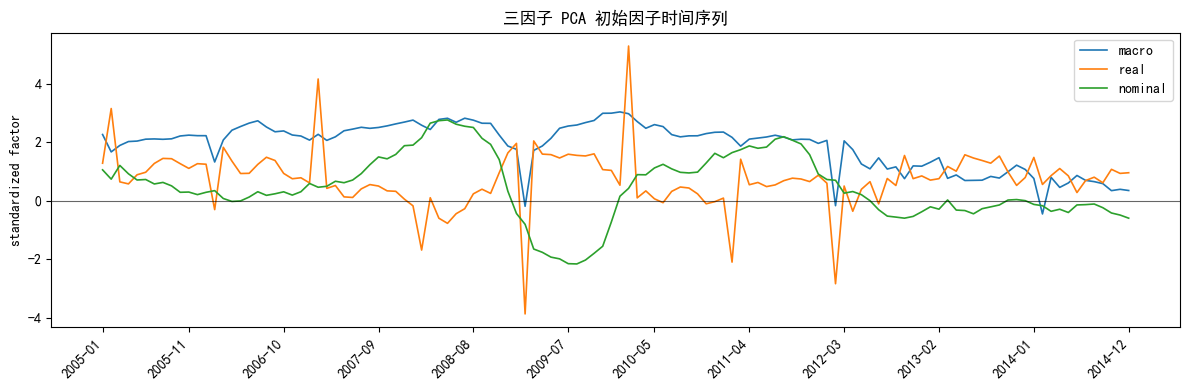

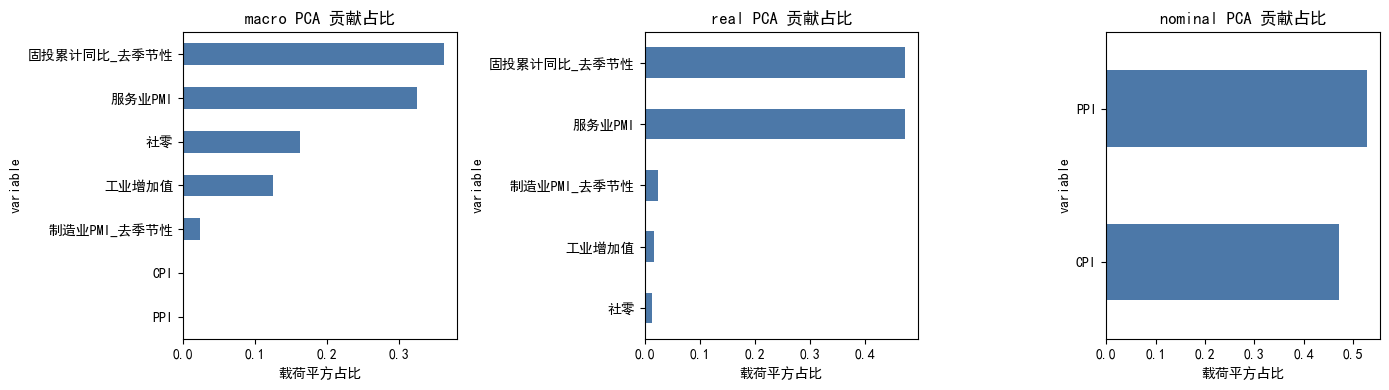

初始 AR 参数前 5 阶：


,rho_1,rho_2,rho_3,rho_4,rho_5
macro,1.019204,-0.726454,0.740413,-0.509962,0.518004
real,0.232885,0.154462,0.087869,0.061537,0.057243
nominal,1.143729,-0.696131,0.741835,-0.587634,0.578284


In [5]:
def first_pc(panel, ref=None):
    bal = panel.dropna()
    if bal.shape[0] < 12 or bal.shape[1] == 0:
        fallback = panel.mean(axis=1, skipna=True).fillna(0.0)
        return fallback, pd.Series(1.0, index=panel.columns)
    mean = bal.mean(axis=0)
    X = bal.to_numpy(float) - mean.to_numpy()[None, :]
    u, s, vt = np.linalg.svd(X, full_matrices=False)
    fac = pd.Series(np.sqrt(len(bal)) * u[:, 0], index=bal.index)
    lam = pd.Series(X.T @ fac.to_numpy() / len(bal), index=bal.columns)
    if ref in bal.columns and fac.corr(bal[ref]) < 0:
        fac = -fac
        lam = -lam
    cen = panel[lam.index] - mean
    denom = lam.pow(2)
    denom_available = cen.notna().mul(denom, axis=1).sum(axis=1)
    proj = cen.mul(lam, axis=1).sum(axis=1, skipna=True) / denom_available
    return proj.replace([np.inf, -np.inf], np.nan).interpolate(limit_direction='both').fillna(0.0), lam


def subtract_factor_component(panel, factor, lam):
    aligned_lam = lam.reindex(panel.columns).fillna(0.0)
    fitted = pd.DataFrame(
        np.outer(factor.reindex(panel.index).to_numpy(float), aligned_lam.to_numpy(float)),
        index=panel.index,
        columns=panel.columns,
    )
    return panel - fitted


def pca_diagnostics(panel, lam):
    bal = panel[lam.index].dropna()
    if bal.shape[0] < 12 or bal.shape[1] == 0:
        return np.nan, np.nan, len(bal), bal.shape[1]
    X = bal.to_numpy(float) - bal.mean(axis=0).to_numpy()[None, :]
    _, s, _ = np.linalg.svd(X, full_matrices=False)
    fac = (X @ lam.to_numpy(float)) / max(float(lam.pow(2).sum()), 1e-12)
    fitted = np.outer(fac, lam.to_numpy(float))
    explained = float(s[0] ** 2 / np.sum(s ** 2)) if np.sum(s ** 2) > 0 else np.nan
    objective = float(np.mean((X - fitted) ** 2))
    return explained, objective, len(bal), bal.shape[1]


init_cols = {'macro': MACRO_COLS, 'real': REAL_COLS, 'nominal': NOMINAL_COLS}
refs = {'macro': '工业增加值', 'real': '工业增加值', 'nominal': 'PPI'}
alpha0 = {}
pca_lam = {}
pca_source_panels = {}
pca_methods = {}

# 1. Global / macro factor: first PC from all selected monthly indicators.
pca_source_panels['macro'] = z[init_cols['macro']]
alpha0['macro'], pca_lam['macro'] = first_pc(pca_source_panels['macro'], refs.get('macro'))
alpha0['macro'] = alpha0['macro'].reindex(z.index).interpolate(limit_direction='both').fillna(0.0)
pca_methods['macro'] = 'global_first_pc_all_monthly'

# 2. Block factors: first PC from residual panels after removing the macro component.
for f in ['real', 'nominal']:
    raw_panel = z[init_cols[f]]
    pca_source_panels[f] = subtract_factor_component(raw_panel, alpha0['macro'], pca_lam['macro'])
    alpha0[f], pca_lam[f] = first_pc(pca_source_panels[f], refs.get(f))
    alpha0[f] = alpha0[f].reindex(z.index).interpolate(limit_direction='both').fillna(0.0)
    pca_methods[f] = f'residual_{f}_first_pc_after_macro'

pca_summary_rows = []
pca_contrib_rows = []
for f in FACTOR_NAMES:
    panel_f = pca_source_panels[f]
    lam = pca_lam[f]
    explained, objective, balanced_rows, balanced_cols = pca_diagnostics(panel_f, lam)
    ref_corr = float(alpha0[f].corr(panel_f[refs[f]])) if refs[f] in panel_f.columns else np.nan
    pca_summary_rows.append({
        'factor': f,
        'method': pca_methods[f],
        'reference_variable': refs.get(f),
        'reference_corr': ref_corr,
        'balanced_rows': balanced_rows,
        'balanced_cols': balanced_cols,
        'explained_ratio_1': explained,
        'pca_objective_v': objective,
    })
    square = lam.pow(2)
    total = float(square.sum())
    balanced_columns = panel_f.dropna().columns
    for col in lam.index:
        pca_contrib_rows.append({
            'factor': f,
            'variable': col,
            '载荷lambda': float(lam.loc[col]),
            '载荷绝对值': float(abs(lam.loc[col])),
            '载荷平方': float(square.loc[col]),
            '观测数': int(panel_f[col].notna().sum()),
            '缺失率': float(panel_f[col].isna().mean()),
            '进入平衡PCA块': bool(col in balanced_columns),
            '贡献占比': float(square.loc[col] / total) if total > 0 else np.nan,
        })
pca_summary = pd.DataFrame(pca_summary_rows)
pca_contribution_table = pd.DataFrame(pca_contrib_rows)
pca_contribution_table['贡献排名'] = pca_contribution_table.groupby('factor')['贡献占比'].rank(ascending=False, method='min').astype('Int64')
pca_contribution_table = pca_contribution_table.sort_values(['factor', '贡献占比'], ascending=[True, False])

print('三因子 PCA 初始化方式：先全体月度变量提取 macro/global 因子，再对扣除 macro 后的 real/nominal 残差分别提取第一主成分；PCA 只用于 EM 初始值。')
display(pca_summary)
print('各变量对对应 PCA 第一主成分的贡献，按载荷平方占比排序：')
display(pca_contribution_table)

alpha0_df = pd.DataFrame(alpha0)
display(alpha0_df.describe().T)
fig, ax = plt.subplots(figsize=(12, 4))
plot_alpha = alpha0_df.loc[TRAIN_START:TRAIN_END].copy(); plot_alpha.index = plot_alpha.index.astype(str)
plot_alpha.plot(ax=ax, linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
tick_positions = np.linspace(0, len(plot_alpha.index) - 1, min(12, len(plot_alpha.index)), dtype=int)
ax.set_xticks(tick_positions); ax.set_xticklabels([plot_alpha.index[i] for i in tick_positions], rotation=45, ha='right')
ax.set_title('三因子 PCA 初始因子时间序列')
ax.set_ylabel('standardized factor')
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(FACTOR_NAMES), figsize=(14, 4), sharex=False)
if len(FACTOR_NAMES) == 1: axes = [axes]
for ax, f in zip(axes, FACTOR_NAMES):
    plot_contrib = pca_contribution_table.loc[pca_contribution_table['factor'] == f].set_index('variable')['贡献占比'].sort_values(ascending=True)
    plot_contrib.plot(kind='barh', ax=ax, color='#4c78a8')
    ax.set_title(f'{f} PCA 贡献占比')
    ax.set_xlabel('载荷平方占比')
fig.tight_layout(); plt.show()


def ar_ols(y, p):
    v = y.astype(float).interpolate(limit_direction='both').fillna(0.0).to_numpy(); X = []; Y = []
    for t in range(p, len(v)): X.append(v[t-p:t][::-1]); Y.append(v[t])
    X = np.asarray(X); Y = np.asarray(Y)
    if len(Y) <= p or np.linalg.matrix_rank(X) == 0:
        rho = np.zeros(p); rho[0] = 0.8
    else: rho = np.linalg.solve(X.T @ X + 1e-6 * np.eye(p), X.T @ Y)
    return pd.Series(rho, index=[f'rho_{i}' for i in range(1, p + 1)])


def accum(a):
    out = []; prev = 0.0
    for m, x in a.items():
        val = sw(m) * prev + float(x); out.append(val); prev = val
    return pd.Series(out, index=a.index)


ar = pd.DataFrame({f: ar_ols(alpha0[f], FACTOR_AR_ORDER) for f in FACTOR_NAMES}).T
alpha_state0 = {f: alpha0[f].shift(-1).ffill().fillna(0.0) for f in FACTOR_NAMES}
S0 = {f: accum(alpha_state0[f]) for f in FACTOR_NAMES}
xi0 = pd.DataFrame(0.0, index=z.index, columns=STATE_NAMES)
for f in FACTOR_NAMES:
    xi0[f'{f}_alpha_t'] = alpha_state0[f]
    xi0[f'{f}_alpha_lag1'] = alpha0[f]
    for lag in range(2, FACTOR_AR_ORDER): xi0[f'{f}_alpha_lag{lag}'] = alpha0[f].shift(lag - 1).bfill().fillna(0.0)
    xi0[s_name(f)] = S0[f]
    xi0[s_lag1_name(f)] = S0[f].shift(1).bfill().fillna(0.0)
print('初始 AR 参数前 5 阶：')
display(ar.iloc[:, :5])


PCA 结果分析：
1. 这里展示的是三个初始因子，不是最终 EM 平滑因子。
2. `macro` 反映所有月度变量的共同波动，`real` 更偏实际活动，`nominal` 更偏价格变量。
3. PCA 贡献占比只解释初始化来源，不等同于最终三因子 loading 或 GDP 解释贡献。

### 9.2 累加器与高阶状态初始值

根据 Harvey 递推累加器：

$$
S_t^{(0)} = s_t S_{t-1}^{(0)} + \alpha_t^{(0)}
$$

同时参考论文中有限阶动态因子设定，将状态向量扩展为：

$$
\xi_t^{(0)} =
\begin{bmatrix}
\alpha_t^{(0)} & \alpha_{t-1}^{(0)} & \cdots & \alpha_{t-p+1}^{(0)} & S_t^{(0)}
\end{bmatrix}'
$$

其中 `FACTOR_AR_ORDER = p`。










三因子版对每个因子分别递推一个 `S_t`，并把三个因子的 AR lag 和累加器拼接成完整状态向量。

In [6]:
display(xi0.loc[TRAIN_START:TRAIN_START + 5, STATE_NAMES])


,macro_alpha_t,macro_alpha_lag1,macro_alpha_lag2,macro_alpha_lag3,macro_alpha_lag4,macro_alpha_lag5,macro_alpha_lag6,macro_alpha_lag7,macro_alpha_lag8,macro_alpha_lag9,macro_alpha_lag10,macro_alpha_lag11,macro_alpha_lag12,macro_alpha_lag13,macro_alpha_lag14,macro_S_t,macro_S_lag1,real_alpha_t,real_alpha_lag1,real_alpha_lag2,real_alpha_lag3,real_alpha_lag4,real_alpha_lag5,real_alpha_lag6,real_alpha_lag7,real_alpha_lag8,real_alpha_lag9,real_alpha_lag10,real_alpha_lag11,real_alpha_lag12,real_alpha_lag13,real_alpha_lag14,real_S_t,real_S_lag1,nominal_alpha_t,nominal_alpha_lag1,nominal_alpha_lag2,nominal_alpha_lag3,nominal_alpha_lag4,nominal_alpha_lag5,nominal_alpha_lag6,nominal_alpha_lag7,nominal_alpha_lag8,nominal_alpha_lag9,nominal_alpha_lag10,nominal_alpha_lag11,nominal_alpha_lag12,nominal_alpha_lag13,nominal_alpha_lag14,nominal_S_t,nominal_S_lag1
2005-01,1.672574,2.268627,2.304398,2.419863,2.447919,2.408077,2.465083,2.500819,3.200325,3.632848,3.891355,4.496923,0.027182,2.273682,2.318931,1.672574,6.992887,3.158374,1.284718,1.447833,1.438700,1.497737,1.705698,1.780832,1.580144,1.271220,2.829196,3.524809,4.518088,0.027890,1.759481,1.830933,3.158374,4.171251,0.739810,1.058398,1.307123,1.747082,1.913896,1.783216,1.726142,1.646778,1.388688,1.130336,0.776033,0.467015,0.753765,0.684556,0.474560,0.739810,4.112603
2005-02,1.894460,1.672574,2.268627,2.304398,2.419863,2.447919,2.408077,2.465083,2.500819,3.200325,3.632848,3.891355,4.496923,0.027182,2.273682,3.567034,1.672574,0.646896,3.158374,1.284718,1.447833,1.438700,1.497737,1.705698,1.780832,1.580144,1.271220,2.829196,3.524809,4.518088,0.027890,1.759481,3.805270,3.158374,1.209371,0.739810,1.058398,1.307123,1.747082,1.913896,1.783216,1.726142,1.646778,1.388688,1.130336,0.776033,0.467015,0.753765,0.684556,1.949181,0.739810
2005-03,2.027540,1.894460,1.672574,2.268627,2.304398,2.419863,2.447919,2.408077,2.465083,2.500819,3.200325,3.632848,3.891355,4.496923,0.027182,5.594574,3.567034,0.577505,0.646896,3.158374,1.284718,1.447833,1.438700,1.497737,1.705698,1.780832,1.580144,1.271220,2.829196,3.524809,4.518088,0.027890,4.382775,3.805270,0.923325,1.209371,0.739810,1.058398,1.307123,1.747082,1.913896,1.783216,1.726142,1.646778,1.388688,1.130336,0.776033,0.467015,0.753765,2.872505,1.949181
2005-04,2.043578,2.027540,1.894460,1.672574,2.268627,2.304398,2.419863,2.447919,2.408077,2.465083,2.500819,3.200325,3.632848,3.891355,4.496923,2.043578,5.594574,0.889714,0.577505,0.646896,3.158374,1.284718,1.447833,1.438700,1.497737,1.705698,1.780832,1.580144,1.271220,2.829196,3.524809,4.518088,0.889714,4.382775,0.710850,0.923325,1.209371,0.739810,1.058398,1.307123,1.747082,1.913896,1.783216,1.726142,1.646778,1.388688,1.130336,0.776033,0.467015,0.710850,2.872505
2005-05,2.108786,2.043578,2.027540,1.894460,1.672574,2.268627,2.304398,2.419863,2.447919,2.408077,2.465083,2.500819,3.200325,3.632848,3.891355,4.152364,2.043578,0.976342,0.889714,0.577505,0.646896,3.158374,1.284718,1.447833,1.438700,1.497737,1.705698,1.780832,1.580144,1.271220,2.829196,3.524809,1.866055,0.889714,0.728053,0.710850,0.923325,1.209371,0.739810,1.058398,1.307123,1.747082,1.913896,1.783216,1.726142,1.646778,1.388688,1.130336,0.776033,1.438903,0.710850
2005-06,2.117169,2.108786,2.043578,2.027540,1.894460,1.672574,2.268627,2.304398,2.419863,2.447919,2.408077,2.465083,2.500819,3.200325,3.632848,6.269534,4.152364,1.277516,0.976342,0.889714,0.577505,0.646896,3.158374,1.284718,1.447833,1.438700,1.497737,1.705698,1.780832,1.580144,1.271220,2.829196,3.143572,1.866055,0.575151,0.728053,0.710850,0.923325,1.209371,0.739810,1.058398,1.307123,1.747082,1.913896,1.783216,1.726142,1.646778,1.388688,1.130336,2.014055,1.438903


### 9.3 状态转移参数初始值：AR(p)

参考论文的有限阶动态因子设定，令初始因子满足：

$$
\alpha_t^{(0)} = \rho_1^{(0)}\alpha_{t-1}^{(0)} + \rho_2^{(0)}\alpha_{t-2}^{(0)} + \cdots + \rho_p^{(0)}\alpha_{t-p}^{(0)} + u_t
$$

用 OLS 得到初始 AR(p) 系数。共同因子冲击方差继续采用文献归一化：

$$
Var(u_t)=1
$$

因此残差方差只作为诊断值保留，不作为 Kalman filter 的 $Q_t$ 输入。










三因子版分别对 `macro`、`real`、`nominal` 三个 PCA 初始因子估计 AR(`FACTOR_AR_ORDER`) 初始参数。


In [7]:
def companion_matrix_from_ar_values(values: np.ndarray) -> np.ndarray:
    p = len(values)
    companion = np.zeros((p, p), dtype=float)
    companion[0, :] = values
    if p > 1:
        companion[1:, :-1] = np.eye(p - 1)
    return companion

def ar_spectral_radius_values(values: np.ndarray) -> float:
    eigvals = np.linalg.eigvals(companion_matrix_from_ar_values(values))
    return float(np.max(np.abs(eigvals))) if len(eigvals) else 0.0

ar_init_summary = ar.copy()
ar_init_summary['spectral_radius_diagnostic_no_clip'] = [ar_spectral_radius_values(ar.loc[f].to_numpy(float)) for f in FACTOR_NAMES]
STATE_SHOCK_VARIANCE = 1.0
print(f'state shock variance: {STATE_SHOCK_VARIANCE:.1f}; AR clip=False')
display(ar_init_summary)


state shock variance: 1.0; AR clip=False


,rho_1,rho_2,rho_3,rho_4,rho_5,rho_6,rho_7,rho_8,rho_9,rho_10,rho_11,rho_12,rho_13,rho_14,rho_15,spectral_radius_diagnostic_no_clip
macro,1.019204,-0.726454,0.740413,-0.509962,0.518004,-0.322258,0.326825,-0.155473,0.162090,-0.049177,0.019231,-0.025317,-0.034843,0.008268,-0.021272,0.970317
real,0.232885,0.154462,0.087869,0.061537,0.057243,0.053877,0.051156,0.022745,0.023155,0.028072,0.002044,0.031545,0.049077,-0.004155,-0.026923,0.955012
nominal,1.143729,-0.696131,0.741835,-0.587634,0.578284,-0.495017,0.499487,-0.487779,0.479769,-0.551240,0.552163,-0.066211,-0.099367,-0.084961,0.024317,0.954042


### 9.4 月度变量载荷与误差方差初始值

对每个月度宏观变量单独回归：

$$
x_{i,t} = \lambda_i^{(0)} \alpha_t^{(0)} + \varepsilon_{i,t}
$$

用 OLS 得到：

$$
\lambda_i^{(0)} =
\frac{\sum_t \alpha_t^{(0)} x_{i,t}}{\sum_t (\alpha_t^{(0)})^2}
$$

月度变量误差方差初始值：

$$
h_i^{(0)} = Var\left(x_{i,t} - \lambda_i^{(0)}\alpha_t^{(0)}\right)
$$









三因子版对每个变量只在允许的因子集合内做 OLS 初始化；不允许加载的因子 loading 固定为 0。

In [8]:
def solve_beta(X,y):
    X=np.asarray(X,float); y=np.asarray(y,float)
    if X.ndim==1: X=X[:,None]
    ok=np.isfinite(y)&np.all(np.isfinite(X),axis=1); X=X[ok]; y=y[ok]
    if len(y)==0: return np.zeros(X.shape[1])
    return np.linalg.solve(X.T@X+1e-6*np.eye(X.shape[1]),X.T@y)
def init_loading_h():
    L=pd.DataFrame(0.0,index=model_cols,columns=FACTOR_NAMES); h=pd.Series(1.0,index=model_cols,name='h')
    for c in model_cols:
        fs=allowed[c]; obs=z[c].dropna()
        if c==GDP_COL:
            obs=obs.loc[[m for m in obs.index if gdp_release_obs(m)]]; X=pd.DataFrame({f:xi0[s_lag1_name(f)].reindex(obs.index) for f in fs})
        else:
            X=pd.DataFrame({f:xi0[f'{f}_alpha_lag1'].reindex(obs.index) for f in fs})
        beta=solve_beta(X.to_numpy(),obs.to_numpy())
        for f,b in zip(fs,beta): L.loc[c,f]=b
        resid=obs.to_numpy()-X.to_numpy()@beta; h.loc[c]=max(float(np.nanmean(resid**2)) if len(resid) else 1.0,MIN_H)
    return L.where(mask,0.0),h
L,h=init_loading_h(); display(L); display(h.to_frame())


,macro,real,nominal
GDP同比,0.099308,0.014918,0.000000
服务业PMI,1.453163,-0.947369,0.000000
工业增加值,0.285057,0.071949,0.000000
社零,0.260232,-0.461021,0.000000
CPI,-0.022357,0.000000,0.729146
PPI,-0.085379,0.000000,0.899702
制造业PMI_去季节性,0.247746,-0.157350,0.000000
固投累计同比_去季节性,0.301066,0.870020,0.000000


,h
GDP同比,2.038045
服务业PMI,0.562396
工业增加值,1.776684
社零,1.752586
CPI,0.373599
PPI,0.244577
制造业PMI_去季节性,0.904066
固投累计同比_去季节性,8.770514


### 9.5 GDP 载荷与观测误差方差初始值

GDP 在发布月份加载 `allowed[GDP_COL]` 中允许的上一月 Harvey 累加器 `S_lag1`。当前设置为 `macro + real`：

$$
GDP_t^{std} = \lambda^{macro}_{GDP}S^{macro}_t + \lambda^{real}_{GDP}S^{real}_t + \varepsilon_{GDP,t}
$$

初始 GDP loading 由季度末 GDP 对当前允许的初始累加器做无截距 OLS 得到。


In [9]:
gdp_param_init = pd.Series({
    **{f'lambda_gdp_{f}_init': float(L.loc[GDP_COL, f]) for f in FACTOR_NAMES},
    'h_gdp_init': float(h.loc[GDP_COL]),
    'gdp_obs_used': int(z.loc[[m for m in z.index if gdp_release_obs(m)], GDP_COL].dropna().shape[0]),
})
display(gdp_param_init.to_frame('value'))


,value
lambda_gdp_macro_init,0.099308
lambda_gdp_real_init,0.014918
lambda_gdp_nominal_init,0.000000
h_gdp_init,2.038045
gdp_obs_used,137.000000


### 9.6 汇总初始对象

后续 Kalman filter 需要的初始对象包括：

$$
\xi_t^{(0)},\quad \rho_1^{(0)},\ldots,\rho_p^{(0)},\quad Var(u_t)=1,\quad \lambda_i^{(0)},\quad h_i^{(0)},\quad h_{GDP}^{(0)}
$$

这里先构造完整观测误差协方差初始矩阵：

$$
H^{(0)} = diag\left(h_{GDP}^{(0)}, h_1^{(0)}, h_2^{(0)}, \ldots, h_N^{(0)}\right)
$$

注意：$H^{(0)}$ 仍然是初始值。后续 EM 更新时，$H$ 要使用 smoother 给出的状态均值和状态协方差来更新。










In [10]:
H_init = pd.DataFrame(np.diag(h.loc[model_cols_valid].to_numpy(float)), index=model_cols_valid, columns=model_cols_valid)
initialization_artifacts = {
    'alpha_init': alpha0_df,
    'S_init': pd.DataFrame(S0),
    'xi_init': xi0,
    'ar_params_init': ar,
    'pca_block_loadings': pca_lam,
    'pca_summary': pca_summary,
    'state_shock_variance': STATE_SHOCK_VARIANCE,
    'loading_init': L,
    'h_init': h,
    'H_init': H_init,
}
print('Initialization objects generated:')
print(', '.join(initialization_artifacts.keys()))
display(pd.concat([L.add_prefix('lambda_'), h.rename('h_init')], axis=1))


Initialization objects generated:
alpha_init, S_init, xi_init, ar_params_init, pca_block_loadings, pca_summary, state_shock_variance, loading_init, h_init, H_init


,lambda_macro,lambda_real,lambda_nominal,h_init
GDP同比,0.099308,0.014918,0.000000,2.038045
服务业PMI,1.453163,-0.947369,0.000000,0.562396
工业增加值,0.285057,0.071949,0.000000,1.776684
社零,0.260232,-0.461021,0.000000,1.752586
CPI,-0.022357,0.000000,0.729146,0.373599
PPI,-0.085379,0.000000,0.899702,0.244577
制造业PMI_去季节性,0.247746,-0.157350,0.000000,0.904066
固投累计同比_去季节性,0.301066,0.870020,0.000000,8.770514


### 9.7 各观测变量自身的 AR(p) 诊断

主模型的状态转移使用三个 PCA 初始因子的 AR(`FACTOR_AR_ORDER`) 初始化。这里额外对每个观测变量自身估计一次无截距 AR(`FACTOR_AR_ORDER`)，仅用于诊断变量自身的持续性：

$$
x_{i,t} = \phi_{i,1}x_{i,t-1}+\phi_{i,2}x_{i,t-2}+\cdots+\phi_{i,15}x_{i,t-15}+u_{i,t}
$$

缺失值较多的变量可能没有足够连续样本，表中会标记为估计失败。


In [11]:
observed_ar15_rows = []
for col in model_cols_valid:
    series = z_train_df[col].astype(float).dropna()
    row = {'variable': col, 'n_obs': int(series.shape[0]), 'ar_effective_rows': 0, 'estimated': False, 'spectral_radius': np.nan, 'note': ''}
    try:
        coef = ar_ols(series.reindex(z_train_df.index).interpolate(limit_direction='both').fillna(0.0), FACTOR_AR_ORDER)
        row['ar_effective_rows'] = max(int(series.shape[0] - FACTOR_AR_ORDER), 0)
        row['estimated'] = True
        row['spectral_radius'] = ar_spectral_radius_values(coef.to_numpy(float))
    except Exception as exc:
        row['note'] = str(exc)
    observed_ar15_rows.append(row)
observed_ar15_summary = pd.DataFrame(observed_ar15_rows).set_index('variable')
display(observed_ar15_summary)


,n_obs,ar_effective_rows,estimated,spectral_radius,note
variable,,,,,
GDP同比,40,25,True,0.933772,
服务业PMI,34,19,True,0.987910,
工业增加值,120,105,True,0.952384,
社零,118,103,True,0.970297,
CPI,120,105,True,0.974592,
PPI,120,105,True,0.960118,
制造业PMI_去季节性,119,104,True,0.945426,
固投累计同比_去季节性,110,95,True,0.993735,


## 10. 构造 Kalman filter 系统矩阵

本节按文献附录 A.1-A.2 的口径，先把每一期 Kalman filter 需要的状态方程和观测方程矩阵组装出来。

文献状态方程写作：

$$
\alpha_{t+1}=T_t\alpha_t+R_t\eta_t,
\qquad
\eta_t\sim N(0,Q)
$$

本文 notebook 的状态向量是月频版本：

$$
\xi_t=
\begin{bmatrix}
\alpha_t & \alpha_{t-1} & \cdots & \alpha_{t-p+1} & S_t
\end{bmatrix}'
$$

其中 $S_t$ 是季度 GDP 对应的 Harvey sum accumulator：

$$
S_t=s_t S_{t-1}+\alpha_t
$$

观测方程为：

$$
y_t=Z_t\xi_t+\varepsilon_t,
\qquad
\varepsilon_t\sim N(0,H)
$$

由于每期有些变量缺失，文献用选择矩阵 $W_t$ 处理部分观测：

$$
y_t^*=W_t y_t
$$

$$
Z_t^*=W_t Z_t
$$

$$
H_t^*=W_t H W_t'
$$

所以本节输出的核心对象是：

$$
T_t,\quad Q_t,\quad y_t^*,\quad Z_t^*,\quad H_t^*,\quad W_t
$$

**与原文的必要差异**

1. 原文是周频金融条件指数，状态中有 monthly average、monthly sum、quarterly sum 三个 accumulator；本 notebook 是月频宏观变量和季度 GDP，因此只保留季度 sum accumulator $S_t$。
2. 原文记号用 $\alpha_t$ 表示整个状态；本 notebook 为了区分共同因子和状态向量，用 $\xi_t$ 表示状态向量，用 $\alpha_t$ 表示状态向量里的当期共同因子。
3. 原文将状态扰动方差归一化；本 notebook 同样设 $Var(\eta_t)=1$。

In [12]:
def build_state_transition_system(month: pd.Period, ar_params: pd.DataFrame):
    F_t = pd.DataFrame(trans(month, ar_params), index=STATE_NAMES, columns=STATE_NAMES)
    Q_t = pd.DataFrame(Q, index=STATE_NAMES, columns=STATE_NAMES)
    return F_t, Q_t

example_month = TRAIN_START
F_example, Q_example = build_state_transition_system(example_month, ar)
Z_example = obs_mat(example_month, L)
print(f'Example month: {example_month}; state_dim={len(STATE_NAMES)}; observed_dim={len(model_cols_valid)}')
display(F_example.iloc[:8, :8])
display(Q_example.iloc[:8, :8])
display(Z_example.loc[model_cols_valid, Z_example.columns[Z_example.abs().sum(axis=0) > 0]])


Example month: 2005-01; state_dim=51; observed_dim=8


,macro_alpha_t,macro_alpha_lag1,macro_alpha_lag2,macro_alpha_lag3,macro_alpha_lag4,macro_alpha_lag5,macro_alpha_lag6,macro_alpha_lag7
macro_alpha_t,1.019204,-0.726454,0.740413,-0.509962,0.518004,-0.322258,0.326825,-0.155473
macro_alpha_lag1,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
macro_alpha_lag2,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
macro_alpha_lag3,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
macro_alpha_lag4,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
macro_alpha_lag5,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
macro_alpha_lag6,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
macro_alpha_lag7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


,macro_alpha_t,macro_alpha_lag1,macro_alpha_lag2,macro_alpha_lag3,macro_alpha_lag4,macro_alpha_lag5,macro_alpha_lag6,macro_alpha_lag7
macro_alpha_t,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,macro_alpha_lag1,macro_S_lag1,real_alpha_lag1,real_S_lag1,nominal_alpha_lag1
GDP同比,0.000000,0.099308,0.000000,0.014918,0.000000
服务业PMI,1.453163,0.000000,-0.947369,0.000000,0.000000
工业增加值,0.285057,0.000000,0.071949,0.000000,0.000000
社零,0.260232,0.000000,-0.461021,0.000000,0.000000
CPI,-0.022357,0.000000,0.000000,0.000000,0.729146
PPI,-0.085379,0.000000,0.000000,0.000000,0.899702
制造业PMI_去季节性,0.247746,0.000000,-0.157350,0.000000,0.000000
固投累计同比_去季节性,0.301066,0.000000,0.870020,0.000000,0.000000


## 11. Kalman Filter Forward Recursion

This section follows the Durbin and Koopman notation used in Appendix A.1 of the paper. Given $a_t$ and $P_t$:

$$
v_t = y_t - Z_t a_t
$$

$$
F_t = Z_tP_tZ_t' + H
$$

$$
K_t = T_tP_tZ_t'F_t^{-1}
$$

$$
L_t = T_t - K_tZ_t
$$

$$
a_{t+1} = T_ta_t + K_tv_t
$$

$$
P_{t+1} = T_tP_tL_t' + RQR'
$$

With missing observations, the code uses the selected system:

$$
y_t^*,\quad Z_t^*,\quad H_t^*
$$

so that:

$$
v_t = y_t^* - Z_t^* a_t
$$

$$
F_t^* = Z_t^*P_tZ_t^{*'} + H_t^*
$$

In code, `Omega_t` is the paper's $F_t^*$, named differently to avoid collision with the transition matrix. The log likelihood follows paper Eq. (4), omitting the normal constant.


In [13]:
def pinv_solve(A, B):
    try:
        return np.linalg.solve(A, B)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A) @ B


def _solve_symmetric(A, B):
    A = 0.5 * (A + A.T)
    try:
        return np.linalg.solve(A, B)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A) @ B


def _safe_slogdet(A):
    A = 0.5 * (A + A.T)
    sign, logdet = np.linalg.slogdet(A)
    if sign > 0:
        return float(logdet)
    jitter = 1e-10 * max(float(np.nanmax(np.abs(np.diag(A)))) if A.size else 1.0, 1.0)
    for _ in range(6):
        sign, logdet = np.linalg.slogdet(A + jitter * np.eye(A.shape[0]))
        if sign > 0:
            return float(logdet)
        jitter *= 10.0
    return float(np.log(max(np.linalg.det(A + jitter * np.eye(A.shape[0])), 1e-12)))


FACTOR_POS = {f: i for i, f in enumerate(FACTOR_NAMES)}
FACTOR_ALPHA_POS = {f: pos[f'{f}_alpha_t'] for f in FACTOR_NAMES}
FACTOR_S_POS = {f: pos[s_name(f)] for f in FACTOR_NAMES}
FACTOR_S_LAG1_POS = {f: pos[s_lag1_name(f)] for f in FACTOR_NAMES}
FACTOR_AR_POS = {f: np.array([pos[n] for n in FACTOR_A[f]], dtype=int) for f in FACTOR_NAMES}
MODEL_COL_POS = {c: i for i, c in enumerate(model_cols)}

TARGET_STATE_POS = {}
TARGET_FACTOR_POS = {}
for c in model_cols:
    if c == GDP_COL:
        TARGET_STATE_POS[c] = np.array([FACTOR_S_LAG1_POS[f] for f in allowed[c]], dtype=int)
    else:
        TARGET_STATE_POS[c] = np.array([pos[f'{f}_alpha_lag1'] for f in allowed[c]], dtype=int)
    TARGET_FACTOR_POS[c] = np.array([FACTOR_POS[f] for f in allowed[c]], dtype=int)


def _build_fast_panel_cache(panel):
    months = list(panel.index)
    y = panel.loc[months, model_cols].to_numpy(float)
    obs_idx = [np.flatnonzero(np.isfinite(y[i])) for i in range(len(months))]
    q_end_flags = np.array([q_end(m) for m in months], dtype=bool)
    gdp_release_flags = np.array([gdp_release_obs(m) for m in months], dtype=bool)
    q_start_flags = np.array([q_start(m) for m in months], dtype=bool)
    obs_for_update = {}
    for c in model_cols:
        j = MODEL_COL_POS[c]
        valid = np.flatnonzero(np.isfinite(y[:, j]))
        if c == GDP_COL:
            valid = np.array([i for i in valid if gdp_release_flags[i]], dtype=int)
        obs_for_update[c] = valid
    return {
        'months': months,
        'y': y,
        'obs_idx': obs_idx,
        'q_end': q_end_flags,
        'gdp_release': gdp_release_flags,
        'q_start': q_start_flags,
        'obs_for_update': obs_for_update,
    }


def _transition_array(month_is_q_start, ar_values):
    T = np.zeros((nstate, nstate), dtype=float)
    st = 0.0 if month_is_q_start else 1.0
    for f in FACTOR_NAMES:
        ap = FACTOR_AR_POS[f]
        sp = FACTOR_S_POS[f]
        spl = FACTOR_S_LAG1_POS[f]
        rho = ar_values[FACTOR_POS[f]]
        T[ap[0], ap] = rho
        for lag in range(1, FACTOR_AR_ORDER):
            T[ap[lag], ap[lag - 1]] = 1.0
        T[sp, ap] = rho
        T[sp, sp] = st
        T[spl, sp] = 1.0
    return T


def _loading_array(L):
    return L.reindex(index=model_cols, columns=FACTOR_NAMES).fillna(0.0).to_numpy(float)


def _h_array(h):
    return h.reindex(model_cols).fillna(1.0).to_numpy(float)


def _ar_array(ar):
    return ar.reindex(index=FACTOR_NAMES, columns=[f'rho_{i}' for i in range(1, FACTOR_AR_ORDER + 1)]).fillna(0.0).to_numpy(float)


def _observed_Z(obs, q_end_flag, gdp_release_flag, L_arr):
    Z = np.zeros((len(obs), nstate), dtype=float)
    for r, j in enumerate(obs):
        c = model_cols[j]
        if c == GDP_COL and not gdp_release_flag:
            continue
        state_idx = TARGET_STATE_POS[c]
        factor_idx = TARGET_FACTOR_POS[c]
        Z[r, state_idx] = L_arr[j, factor_idx]
    return Z


def kfilter_fast(panel_cache, ar, L, h, a1=None, P1=None):
    months = panel_cache['months']; n = len(months)
    y = panel_cache['y']; obs_idx = panel_cache['obs_idx']
    ar_arr = _ar_array(ar); L_arr = _loading_array(L); h_arr = _h_array(h)
    ap = np.zeros((n, nstate), dtype=float); Pp = np.zeros((n, nstate, nstate), dtype=float)
    af = np.zeros((n, nstate), dtype=float); Pf = np.zeros((n, nstate, nstate), dtype=float)
    Ts = np.zeros((n, nstate, nstate), dtype=float)
    a = np.zeros(nstate, dtype=float) if a1 is None else np.asarray(a1, dtype=float).copy()
    P = np.eye(nstate, dtype=float) * 10.0 if P1 is None else np.asarray(P1, dtype=float).copy()
    ll = 0.0
    eye_cache = {}
    for i in range(n):
        if i == 0:
            T = np.eye(nstate, dtype=float)
        else:
            T = _transition_array(panel_cache['q_start'][i], ar_arr)
            a = T @ a
            P = T @ P @ T.T + Q
            P = 0.5 * (P + P.T)
        Ts[i] = T; ap[i] = a; Pp[i] = P
        obs = obs_idx[i]
        if len(obs):
            Z = _observed_Z(obs, panel_cache['q_end'][i], panel_cache['gdp_release'][i], L_arr)
            yv = y[i, obs]
            H = np.diag(np.maximum(h_arr[obs], MIN_H))
            v = yv - Z @ a
            F = Z @ P @ Z.T + H
            F = 0.5 * (F + F.T)
            invv = _solve_symmetric(F, v)
            Finv_ZP = _solve_symmetric(F, Z @ P)
            K = Finv_ZP.T
            ll += -0.5 * (_safe_slogdet(F) + float(v.T @ invv))
            a = a + K @ v
            P = P - K @ Z @ P
            P = 0.5 * (P + P.T)
        af[i] = a; Pf[i] = P
    return {'months': months, 'ap': ap, 'Pp': Pp, 'af': af, 'Pf': Pf, 'Ts': Ts, 'loglike': float(ll), 'panel_cache': panel_cache}


def smooth_fast(fr, return_frames=False):
    months = fr['months']; n = len(months)
    a = fr['af'].copy(); P = fr['Pf'].copy()
    for i in range(n - 2, -1, -1):
        J = fr['Pf'][i] @ fr['Ts'][i + 1].T @ np.linalg.pinv(fr['Pp'][i + 1])
        a[i] = fr['af'][i] + J @ (a[i + 1] - fr['ap'][i + 1])
        P[i] = fr['Pf'][i] + J @ (P[i + 1] - fr['Pp'][i + 1]) @ J.T
        P[i] = 0.5 * (P[i] + P[i].T)
    out = {'state_array': a, 'cov_array': P, 'months': months}
    if return_frames:
        out['state'] = pd.DataFrame(a, index=months, columns=STATE_NAMES)
        out['cov'] = {m: pd.DataFrame(P[i], index=STATE_NAMES, columns=STATE_NAMES) for i, m in enumerate(months)}
    return out


def _ar_ols_array(v, p):
    v = np.asarray(v, dtype=float)
    X = []; Y = []
    for t in range(p, len(v)):
        X.append(v[t - p:t][::-1]); Y.append(v[t])
    X = np.asarray(X, dtype=float); Y = np.asarray(Y, dtype=float)
    if len(Y) <= p or np.linalg.matrix_rank(X) == 0:
        rho = np.zeros(p, dtype=float); rho[0] = 0.8
    else:
        rho = np.linalg.solve(X.T @ X + 1e-6 * np.eye(p), X.T @ Y)
    return rho


def update_ar_fast(state_array):
    arr = np.zeros((len(FACTOR_NAMES), FACTOR_AR_ORDER), dtype=float)
    for f in FACTOR_NAMES:
        arr[FACTOR_POS[f]] = _ar_ols_array(state_array[:, FACTOR_ALPHA_POS[f]], FACTOR_AR_ORDER)
    return pd.DataFrame(arr, index=FACTOR_NAMES, columns=[f'rho_{i}' for i in range(1, FACTOR_AR_ORDER + 1)])


def update_L_h_fast(panel_cache, state_array, cov_array):
    y = panel_cache['y']
    L_arr = np.zeros((len(model_cols), len(FACTOR_NAMES)), dtype=float)
    h_new = np.ones(len(model_cols), dtype=float)
    for c in model_cols:
        j = MODEL_COL_POS[c]
        obs = panel_cache['obs_for_update'][c]
        if len(obs) == 0:
            h_new[j] = 1.0
            continue
        states = TARGET_STATE_POS[c]
        factors = TARGET_FACTOR_POS[c]
        k = len(states)
        num = np.zeros(k, dtype=float)
        den = np.zeros((k, k), dtype=float)
        for i in obs:
            mu = state_array[i, states]
            V = cov_array[i][np.ix_(states, states)]
            num += float(y[i, j]) * mu
            den += V + np.outer(mu, mu)
        beta = pinv_solve(den + 1e-8 * np.eye(k), num)
        L_arr[j, factors] = beta
        hs = 0.0
        for i in obs:
            yy = float(y[i, j])
            mu = state_array[i, states]
            V = cov_array[i][np.ix_(states, states)]
            second = V + np.outer(mu, mu)
            hs += yy ** 2 - 2.0 * yy * float(beta @ mu) + float(beta @ second @ beta)
        h_new[j] = max(float(hs / len(obs)), MIN_H)
    Lnew = pd.DataFrame(L_arr, index=model_cols, columns=FACTOR_NAMES).where(mask, 0.0)
    hnew = pd.Series(h_new, index=model_cols, name='h')
    return Lnew, hnew


def m_step_fast(panel_cache, state_array, cov_array, ar_params_old=None, loading_old=None, h_old=None):
    """One three-factor EM M-step on fast numpy arrays.

    This keeps the same public function name used by the original single-factor
    notebook while dispatching to the three-factor block-loading updates.
    """
    ar_new = update_ar_fast(state_array)
    loading_new, h_new = update_L_h_fast(panel_cache, state_array, cov_array)
    return {'ar': ar_new, 'loading': loading_new, 'h': h_new}


def run_em_fast(panel, ar0, L0, h0):
    panel_cache = _build_fast_panel_cache(panel)
    ar = ar0.copy(); L = L0.copy(); h = h0.copy()
    a1 = xi0.iloc[0].reindex(STATE_NAMES).fillna(0.0).to_numpy(float)
    P1 = np.eye(nstate, dtype=float) * 10.0
    hist = []
    last = None
    print(f'Fast EM start: tol={TOL:g}, state_dim={nstate}, numpy_loop=True, max_iter=None')
    it = 0
    while True:
        it += 1
        iter_t0 = time.perf_counter()
        t0 = time.perf_counter(); fr = kfilter_fast(panel_cache, ar, L, h, a1, P1); filter_seconds = time.perf_counter() - t0
        t0 = time.perf_counter(); sm = smooth_fast(fr, return_frames=False); smoother_seconds = time.perf_counter() - t0
        t0 = time.perf_counter(); ar2 = update_ar_fast(sm['state_array']); L2, h2 = update_L_h_fast(panel_cache, sm['state_array'], sm['cov_array']); m_step_seconds = time.perf_counter() - t0
        a1_next = sm['state_array'][0].copy()
        ll = fr['loglike']
        rel = np.nan if last is None else abs((ll - last) / max(1.0, abs(last)))
        hist.append({
            'iteration': it,
            'loglike': ll,
            'relative_loglike_change': rel,
            'min_h': float(h2.min()),
            'max_h': float(h2.max()),
            'filter_seconds': filter_seconds,
            'smoother_seconds': smoother_seconds,
            'm_step_seconds': m_step_seconds,
            'iteration_seconds': time.perf_counter() - iter_t0,
        })
        print(f"iter {it:03d}: loglike={ll:.6f}, rel_change={rel}, min_h={h2.min():.3g}, time(filter/smoother/M)={filter_seconds:.2f}/{smoother_seconds:.2f}/{m_step_seconds:.2f}s")
        ar, L, h = ar2, L2, h2
        a1 = a1_next
        if last is not None and rel < TOL:
            break
        last = ll
    fr = kfilter_fast(panel_cache, ar, L, h, a1, P1)
    sm = smooth_fast(fr, return_frames=True)
    return {'ar': ar, 'loading': L, 'h': h, 'a1': pd.Series(a1, index=STATE_NAMES), 'history': pd.DataFrame(hist), 'filter': fr, 'smoother': sm}

# Keep the public entry point unchanged for downstream cells.
run_em = run_em_fast


## 12. Kalman Smoother Backward Recursion

Appendix A.1 uses the $r_t$ and $N_t$ backward smoother with terminal conditions:

$$
r_T=0,
\qquad
N_T=0
$$

Backward recursion:

$$
r_{t-1}=Z_t'F_t^{-1}v_t+L_t'r_t
$$

$$
N_{t-1}=Z_t'F_t^{-1}Z_t+L_t'N_tL_t
$$

Smoothed state and covariance:

$$
\hat{\alpha}_t=a_t+P_tr_{t-1}
$$

$$
V_t=P_t-P_tN_{t-1}P_t
$$

The paper also computes the lag-one covariance needed by the EM M-step:

$$
J_t=P_tL_{t-1}'(I-N_{t-1}P_t)
$$

The code returns `smoothed_state`, `smoothed_cov`, and `lag_one_smoothed_cov` for the M-step.


In [14]:
print('RTS smoother functions are defined together with the fast Kalman implementation in section 11.')


RTS smoother functions are defined together with the fast Kalman implementation in section 11.


## 13. EM M-step Following Appendix A.3

Appendix A.3 maximizes the conditional expectation of the complete-data log likelihood. The smoother supplies:

> $$
> E(\alpha_t\mid Y)=\hat{\alpha}_t
> $$

> $$
> Var(\alpha_t\mid Y)=V_t
> $$

> $$
> Cov(\alpha_t,\alpha_{t-1}\mid Y)=J_t'
> $$

The paper's update equations are:

> $$
> T^{new}=BA^{-1}
> $$

> $$
> Z^{new}=ED^{-1}
> $$

Under the restricted measurement structure, each indicator loads on one state element, so loadings and diagonal $H_i$ are updated variable by variable. The EM loop also updates $a_1$ to the first smoothed state and keeps $P_1$ at the baseline initial covariance, as described in Appendix A.3.


### 13.1 Update Transition Dynamics AR(p)

The unrestricted paper update is:

> $$
> T^{new}=BA^{-1}
> $$

For the first row of the AR(`FACTOR_AR_ORDER`) companion block, define:

> $$
> \alpha_t=\rho_1\alpha_{t-1}+\rho_2\alpha_{t-2}+\cdots+\rho_p\alpha_{t-p}+u_t
> $$

> $$
> x_{t-1}=\begin{bmatrix}\alpha_{t-1} & \alpha_{t-2} & \cdots & \alpha_{t-p}\end{bmatrix}'
> $$

Then the corresponding $BA^{-1}$ update is:

> $$
> \rho^{new}=\left[\sum_t E(x_{t-1}x_{t-1}'\mid Y)\right]^{-1}\left[\sum_t E(x_{t-1}\alpha_t\mid Y)\right]
> $$

The companion spectral radius is reported as a diagnostic only; it is not clipped or rescaled.


In [15]:
print('AR M-step is implemented inside update_ar_fast(...), called by m_step_fast(...).')


AR M-step is implemented inside update_ar_fast(...), called by m_step_fast(...).


### 13.2 更新观测载荷 Z

文献 unrestricted 更新为：

> $$
> Z^{new}=ED^{-1}
> $$

其中：

> $$
> D=\sum_{t=1}^{T}E(\xi_t\xi_t'\mid Y)
> $$

> $$
> E=\sum_{t=1}^{T}y_t\hat{\xi}_t'
> $$

但文献随后说明，在模型受限结构下，每个指标只加载到一个状态元素。若变量 $i$ 加载到状态元素 $j$，则：

> $$
> y_{i,t}=\lambda_i\xi_{j,t}+\varepsilon_{i,t}
> $$

只使用该变量实际有观测的时期 $\mathcal{T}_i$：

> $$
> \lambda_i^{new}
> =
> \frac{
> \sum_{t\in\mathcal{T}_i} y_{i,t}\hat{\xi}_{j,t}
> }{
> \sum_{t\in\mathcal{T}_i}E(\xi_{j,t}^2\mid Y)
> }
> $$

其中：

> $$
> E(\xi_{j,t}^2\mid Y)=\hat{\xi}_{j,t}^2+V_{j,j,t}
> $$

本 notebook 使用同一受限载荷更新：月度变量加载到 $\alpha_t$，GDP 加载到 $S_t$。

In [16]:
print('Loading M-step is implemented inside update_L_h_fast(...), respecting the three-factor loading mask.')


Loading M-step is implemented inside update_L_h_fast(...), respecting the three-factor loading mask.


### 13.3 Update Observation Error Variance H

The paper uses diagonal $H$ and updates each observed variable separately. If variable $i$ loads on state element $j$:

> $$
> H_i^{new}=\frac{1}{T_i}\sum_{t\in\mathcal{T}_i}\left(y_{i,t}-\lambda_i^{new}\hat{\xi}_{j,t}\right)^2
> $$

where $\mathcal{T}_i$ contains only periods in which variable $i$ is observed. The code follows this variable-by-variable mean squared smoothed residual update.


In [17]:
print('Diagonal H update is implemented inside update_L_h_fast(...), with MIN_H lower bound.')


Diagonal H update is implemented inside update_L_h_fast(...), with MIN_H lower bound.


### 13.4 One M-step Summary

One M-step is not the final converged estimate. Full training iterates:

> $$
> \text{Kalman filter}\rightarrow\text{Kalman smoother}\rightarrow\text{M-step}
> $$

until the paper Eq. (4) log likelihood is stable. The convergence threshold is:

> $$
> \left|\frac{\log L^{(k)}-\log L^{(k-1)}}{\left(\log L^{(k)}+\log L^{(k-1)}\right)/2}\right|<10^{-6}
> $$

Replication status:

1. Kalman filter uses the paper's $a_t,P_t,K_t,L_t$ recursion.
2. Kalman smoother uses the paper's $r_t,N_t$ recursion and returns lag-one covariance for the M-step.
3. M-step updates AR(`FACTOR_AR_ORDER`), $Z$, and diagonal $H$ following Appendix A.3, with $Var(u_t)=1$ normalization.
4. $a_1$ is updated to the first smoothed state; $P_1$ stays at the baseline initial covariance.


In [18]:
panel_cache_check = _build_fast_panel_cache(z.loc[TRAIN_START:TRAIN_END, model_cols_valid])
fr_check = kfilter_fast(panel_cache_check, ar, L, h)
sm_check = smooth_fast(fr_check, return_frames=True)
m_step_check = m_step_fast(panel_cache_check, sm_check['state_array'], sm_check['cov_array'], ar, L, h)
print(f"One-step M-step check: min_h={float(m_step_check['h'].min()):.3g}, max_h={float(m_step_check['h'].max()):.3g}")
display(m_step_check['loading'])


One-step M-step check: min_h=0.181, max_h=0.885


,macro,real,nominal
GDP同比,0.139566,0.083126,0.000000
服务业PMI,1.012985,-0.687939,0.000000
工业增加值,0.304114,0.109704,0.000000
社零,0.134132,-0.236924,0.000000
CPI,-0.047742,0.000000,0.695363
PPI,-0.021954,0.000000,0.764873
制造业PMI_去季节性,0.319330,0.066908,0.000000
固投累计同比_去季节性,0.158718,0.201736,0.000000


## 14. EM Iteration

This section packages steps 11-13 into the EM loop:

$$
\text{Kalman filter}\rightarrow\text{Kalman smoother}\rightarrow\text{M-step}
$$

The loop updates:

$$
\rho_1,\ldots,\rho_{15}, \quad Z, \quad H, \quad a_1
$$

and keeps the paper normalization:

$$
Var(u_t)=1
$$

The convergence threshold is the paper setting:

$$
\left|\frac{\log L^{(k)}-\log L^{(k-1)}}{(|\log L^{(k)}|+|\log L^{(k-1)}|)/2}\right|<10^{-6}
$$

The measurement structure follows the paper's restricted loading design: each variable loads on one state element, $H$ is diagonal, and missing observations enter through the per-period selection matrix.


### 14.1 参数化 Kalman 系统

前面的第 11 至 13 步使用初始化参数。EM 循环需要每一轮使用当前参数，因此这里重新定义可传入参数的 Kalman 系统函数。










In [19]:
def build_observation_matrix_full_with_params(month: pd.Period, loading_full: pd.DataFrame) -> pd.DataFrame:
    return obs_mat(month, loading_full)

def build_H_from_diag(h_diag: pd.Series) -> pd.DataFrame:
    h_diag = h_diag.loc[model_cols_valid].clip(lower=MIN_H)
    return pd.DataFrame(np.diag(h_diag.to_numpy(float)), index=model_cols_valid, columns=model_cols_valid)

print('Parameterized Kalman system uses the fast numpy arrays defined above.')


Parameterized Kalman system uses the fast numpy arrays defined above.


### 14.2 参数化 Kalman filter 与 smoother

这一步和第 11、12 步公式相同，只是每轮使用当前的 AR(p) 参数、$Z$ 和 $H$。










In [20]:
def run_kalman_filter_with_params(y_panel, start, end, ar_params, loading_full, h_diag, a1=None, P1=None):
    panel_cache = _build_fast_panel_cache(y_panel.loc[start:end, model_cols_valid])
    return kfilter_fast(panel_cache, ar_params, loading_full, h_diag, a1=a1, P1=P1)

def run_kalman_smoother_with_params(filter_results, start, end, ar_params, y_panel=None, loading_full=None, h_diag=None):
    return smooth_fast(filter_results, return_frames=True)


### 14.3 参数化 M-step

这一步沿用第 13 步的文献公式，只把输出改成 EM 循环可使用的新参数。










In [21]:
def m_step_update_params(y_panel, smoothed_state, smoothed_cov, lag_one_smoothed_cov, ar_params_old, loading_old, h_old):
    panel_cache = _build_fast_panel_cache(y_panel.loc[smoothed_state.index, model_cols_valid])
    state_array = smoothed_state.loc[panel_cache['months'], STATE_NAMES].to_numpy(float)
    cov_array = np.stack([smoothed_cov[m].loc[STATE_NAMES, STATE_NAMES].to_numpy(float) for m in panel_cache['months']])
    return m_step_fast(panel_cache, state_array, cov_array, ar_params_old, loading_old, h_old)


### 14.4 Run EM loop

The EM loop uses ordinary relative log-likelihood change `relative_loglike_change < 1e-4` as the handoff criterion. There is no iteration cap. Each iteration prints `rel_change`, minimum H, and timing. Aitken acceleration/early-stop is applied later in the quasi-Newton stage, not here.


Fast EM start: tol=0.0001, state_dim=51, numpy_loop=True, max_iter=None
iter 001: loglike=-873.758090, rel_change=nan, min_h=0.178, time(filter/smoother/M)=0.03/0.17/0.02s
iter 002: loglike=-280.827284, rel_change=0.6785983585428461, min_h=0.129, time(filter/smoother/M)=0.03/0.13/0.02s
iter 003: loglike=-159.265625, rel_change=0.4328698324891786, min_h=0.085, time(filter/smoother/M)=0.02/0.11/0.02s
iter 004: loglike=-146.123783, rel_change=0.08251524023194404, min_h=0.0583, time(filter/smoother/M)=0.02/0.11/0.02s
iter 005: loglike=-158.210750, rel_change=0.08271730859912767, min_h=0.0419, time(filter/smoother/M)=0.02/0.13/0.02s
iter 006: loglike=-149.326314, rel_change=0.05615569886333057, min_h=0.0308, time(filter/smoother/M)=0.02/0.14/0.02s
iter 007: loglike=-147.273304, rel_change=0.013748484180779428, min_h=0.0229, time(filter/smoother/M)=0.02/0.12/0.02s
iter 008: loglike=-137.359406, rel_change=0.06731632977109821, min_h=0.0172, time(filter/smoother/M)=0.02/0.13/0.02s
iter 009: lo

,macro,real,nominal
GDP同比,0.000280,0.011495,0.000000
服务业PMI,0.016968,-0.006013,0.000000
工业增加值,0.001051,0.026897,0.000000
社零,0.004054,0.001808,0.000000
CPI,-0.000599,0.000000,0.102510
PPI,-0.035607,0.000000,0.528381
制造业PMI_去季节性,0.000199,0.023177,0.000000
固投累计同比_去季节性,-0.001800,0.020843,0.000000


最终观测误差方差 H：


,h
GDP同比,0.013718
服务业PMI,0.689613
工业增加值,0.301893
社零,0.670654
CPI,0.017958
PPI,0.000059
制造业PMI_去季节性,0.507737
固投累计同比_去季节性,0.531640


最近 EM history：


,iteration,loglike,relative_loglike_change,min_h,max_h,filter_seconds,smoother_seconds,m_step_seconds,iteration_seconds
309,310,75.254826,0.000808,0.000060,0.690377,0.031779,0.170683,0.035657,0.238229
310,311,75.299521,0.000594,0.000060,0.690225,0.020322,0.151310,0.019111,0.190820
311,312,75.326537,0.000359,0.000060,0.690044,0.023513,0.170036,0.020261,0.213882
312,313,75.339006,0.000166,0.000060,0.689839,0.019413,0.156812,0.020818,0.197110
313,314,75.338484,0.000007,0.000059,0.689613,0.021445,0.137290,0.018264,0.177076


EM timing breakdown:


,mean,max,sum,share_of_iteration_sum
filter_seconds,0.023885,0.052224,7.499779,0.124526
smoother_seconds,0.148660,0.247998,46.679110,0.775059
m_step_seconds,0.019172,0.047527,6.019911,0.099954
iteration_seconds,0.191804,0.295475,60.226550,1.000000


最终 smoothed alpha_t 因子摘要：


,start,end,mean,std,min,max
macro,2005-01,2014-12,0.362868,137.763665,-265.928549,358.542895
real,2005-01,2014-12,-0.014305,30.209796,-54.378431,68.796682
nominal,2005-01,2014-12,0.022933,10.506556,-22.135602,26.817088


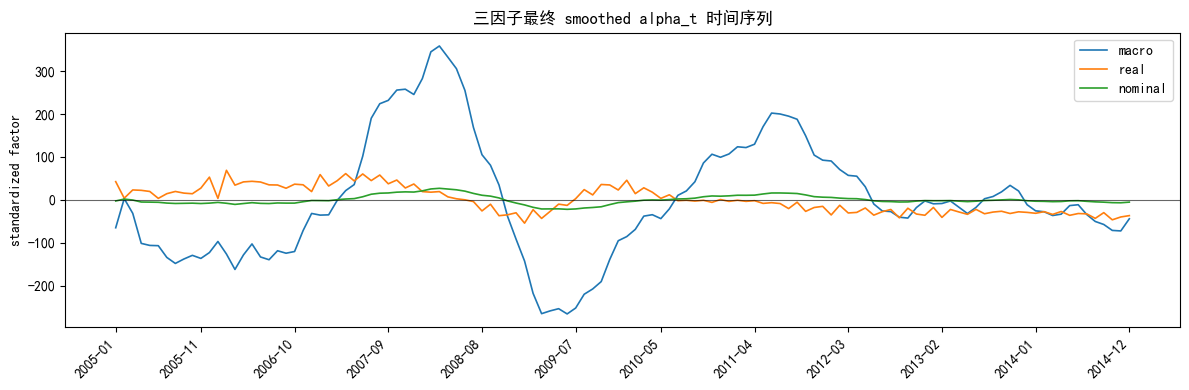

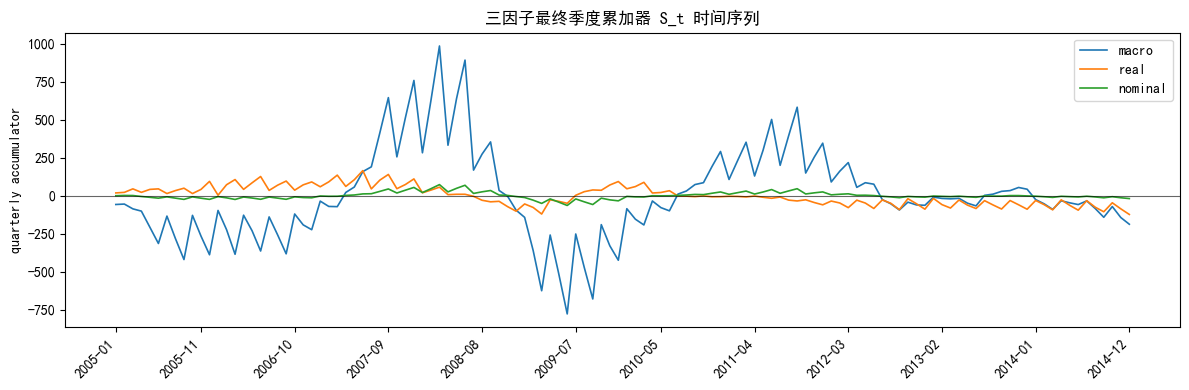

最终 smoothed alpha_t 年度均值：


,macro,real,nominal
year,,,
2005,-101.495236,21.486358,-5.504956
2006,-113.050150,34.992092,-7.135384
2007,124.295724,45.949589,8.933080
2008,178.159797,-6.411871,14.191959
2009,-209.107934,-3.287352,-17.243928
2010,6.032527,9.058493,2.011288
2011,148.601899,-9.984822,11.840538
2012,11.401525,-28.619933,-0.790943
2013,-1.334615,-28.530876,-1.734975


In [22]:
profiling_records = [row for row in globals().get('profiling_records', []) if row.get('phase') != 'EM']
em_start_time = time.perf_counter()
res=run_em(z.loc[TRAIN_START:TRAIN_END,model_cols_valid],ar,L,h)
em_runtime_seconds = time.perf_counter() - em_start_time
profiling_records.append({'phase': 'EM', 'runtime_seconds': em_runtime_seconds})
print(f'EM runtime: {em_runtime_seconds:.2f} seconds ({em_runtime_seconds / 60:.2f} minutes)')
st=res['smoother']['state']; hist=res['history']
paths={
 'ar':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_ar_params.csv','loading':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_loading.csv','h':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_h.csv','state':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_smoothed_state.csv','history':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_history.csv','meta':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_meta.json'}
res['ar'].to_csv(paths['ar'],encoding='utf-8-sig'); res['loading'].to_csv(paths['loading'],encoding='utf-8-sig'); res['h'].rename('h').to_csv(paths['h'],encoding='utf-8-sig'); st.to_csv(paths['state'],encoding='utf-8-sig'); hist.to_csv(paths['history'],encoding='utf-8-sig',index=False)
meta_out={'model':'three_factor_block_loading','train_start':str(TRAIN_START),'train_end':str(TRAIN_END),'factor_ar_order':FACTOR_AR_ORDER,'factors':FACTOR_NAMES,'real_activity_cols':REAL_COLS,'nominal_cols':NOMINAL_COLS,'macro_cols':MACRO_COLS,'allowed_factor_by_variable':allowed,'final_loglike':float(res['filter']['loglike']),'iterations':int(hist['iteration'].max()) if not hist.empty else 0,'a1':res['a1'].to_dict(),'implementation':'fast_numpy_loop','history_has_timing':True,'em_runtime_seconds':float(em_runtime_seconds),'max_iter':None,'relative_loglike_tol':float(TOL),'paper_relative_loglike_tol':float(RELATIVE_LOGLIKE_TOL),'em_to_qn_relative_loglike_tol':float(EM_TO_QN_REL_LOGLIKE_TOL)}
with open(paths['meta'],'w',encoding='utf-8') as f: json.dump(meta_out,f,ensure_ascii=False,indent=2)
for p in paths.values(): print(p)

print('最终 loading：')
display(res['loading'])
print('最终观测误差方差 H：')
display(res['h'].to_frame())
print('最近 EM history：')
display(hist.tail())
if {'filter_seconds','smoother_seconds','m_step_seconds','iteration_seconds'}.issubset(hist.columns):
    timing_summary=hist[['filter_seconds','smoother_seconds','m_step_seconds','iteration_seconds']].agg(['mean','max','sum']).T
    timing_summary['share_of_iteration_sum']=timing_summary['sum']/timing_summary.loc['iteration_seconds','sum']
    print('EM timing breakdown:')
    display(timing_summary)

factor_cols=[f'{f}_alpha_t' for f in FACTOR_NAMES]
factor_path=st[factor_cols].copy(); factor_path.columns=FACTOR_NAMES
factor_summary=factor_path.agg(['mean','std','min','max']).T
factor_summary.insert(0,'start',str(factor_path.index.min()))
factor_summary.insert(1,'end',str(factor_path.index.max()))
print('最终 smoothed alpha_t 因子摘要：')
display(factor_summary)

fig,ax=plt.subplots(figsize=(12,4))
plot_factor=factor_path.copy(); plot_factor.index=plot_factor.index.astype(str)
plot_factor.plot(ax=ax,linewidth=1.2)
ax.axhline(0,color='black',linewidth=0.8,alpha=0.6)
tick_positions=np.linspace(0,len(plot_factor.index)-1,min(12,len(plot_factor.index)),dtype=int)
ax.set_xticks(tick_positions); ax.set_xticklabels([plot_factor.index[i] for i in tick_positions],rotation=45,ha='right')
ax.set_title('三因子最终 smoothed alpha_t 时间序列')
ax.set_ylabel('standardized factor')
fig.tight_layout(); plt.show()

s_cols=[s_name(f) for f in FACTOR_NAMES]
s_path=st[s_cols].copy(); s_path.columns=FACTOR_NAMES
fig,ax=plt.subplots(figsize=(12,4))
plot_s=s_path.copy(); plot_s.index=plot_s.index.astype(str)
plot_s.plot(ax=ax,linewidth=1.2)
ax.axhline(0,color='black',linewidth=0.8,alpha=0.6)
tick_positions=np.linspace(0,len(plot_s.index)-1,min(12,len(plot_s.index)),dtype=int)
ax.set_xticks(tick_positions); ax.set_xticklabels([plot_s.index[i] for i in tick_positions],rotation=45,ha='right')
ax.set_title('三因子最终季度累加器 S_t 时间序列')
ax.set_ylabel('quarterly accumulator')
fig.tight_layout(); plt.show()

factor_by_year=factor_path.copy(); factor_by_year['year']=factor_by_year.index.year
factor_by_year=factor_by_year.groupby('year')[FACTOR_NAMES].mean()
print('最终 smoothed alpha_t 年度均值：')
display(factor_by_year)



em_results = {'ar_params': res['ar'], 'loading': res['loading'], 'h': res['h'], 'history': hist, 'filter_results': res['filter'], 'smoother_results': {'smoothed_state': st, 'smoothed_cov': res['smoother']['cov']}, 'a1': res['a1']}


### 14.5 Quasi-Newton refinement

This section keeps the same position and workflow as the single-factor QN notebook: EM first, then L-BFGS-B refinement on the same Kalman log likelihood.

The three-factor QN step now refines only the three AR(`FACTOR_AR_ORDER`) blocks; block-loading-constrained loadings, diagonal H, and the initial state vector stay fixed at the EM estimates.


In [23]:
RUN_QUASI_NEWTON = globals().get("RUN_QUASI_NEWTON", True)


def relative_loglike_change(loglike: float, previous_loglike: float | None) -> float:
    if previous_loglike is None or not np.isfinite(previous_loglike):
        return np.nan
    denom = max(1.0, abs(float(previous_loglike)))
    return abs(float(loglike) - float(previous_loglike)) / denom


def aitken_loglike_gap(loglikes: list[float]) -> tuple[float, float]:
    if len(loglikes) < 3:
        return np.nan, np.nan
    l0, l1, l2 = [float(x) for x in loglikes[-3:]]
    denom = l0 - 2.0 * l1 + l2
    if not np.isfinite(denom) or abs(denom) < 1e-12:
        return np.nan, np.nan
    limit = l2 - ((l2 - l1) ** 2) / denom
    if not np.isfinite(limit):
        return np.nan, np.nan
    gap = abs(limit - l2) / max(1.0, abs(l2))
    return float(limit), float(gap)


# QN_* convergence controls are defined in the top configuration cell.


class QNEarlyStop(Exception):
    pass


QN_AR_COLUMNS = [f"rho_{i}" for i in range(1, FACTOR_AR_ORDER + 1)]
QN_OPTIMIZED_PARAMETERS = "AR only; loading, H, and initial state are fixed at EM estimates"


def _pack_qn_params(ar_params: pd.DataFrame) -> np.ndarray:
    return ar_params.loc[FACTOR_NAMES, QN_AR_COLUMNS].to_numpy(dtype=float).ravel()


def _unpack_qn_params(
    theta: np.ndarray,
    fixed_loading: pd.DataFrame,
    fixed_h: pd.Series,
    fixed_a1: pd.Series,
):
    theta = np.asarray(theta, dtype=float)
    n_ar = len(FACTOR_NAMES) * FACTOR_AR_ORDER
    ar_values = theta[:n_ar].reshape(len(FACTOR_NAMES), FACTOR_AR_ORDER)
    ar_params = pd.DataFrame(ar_values, index=FACTOR_NAMES, columns=QN_AR_COLUMNS)
    loading = fixed_loading.copy()
    h = fixed_h.clip(lower=MIN_H).copy()
    a1 = fixed_a1.copy()
    return ar_params, loading, h, a1

def run_quasi_newton_refinement(
    em_results: dict,
    y_panel: pd.DataFrame,
    start: pd.Period,
    end: pd.Period,
    max_iter: int | None = None,
):
    """Refine three-factor EM parameters by maximizing the Kalman log likelihood with L-BFGS-B."""
    if not RUN_QUASI_NEWTON:
        print("Quasi-Newton skipped because RUN_QUASI_NEWTON=False.")
        return em_results
    try:
        from scipy.optimize import minimize
    except Exception as exc:
        print(f"Quasi-Newton skipped: scipy.optimize is unavailable ({exc}).")
        return em_results

    y_train = y_panel.loc[start:end, model_cols_valid].copy()
    panel_cache = _build_fast_panel_cache(y_train)
    fixed_loading = em_results["loading"].copy()
    fixed_h = em_results["h"].clip(lower=MIN_H).copy()
    fixed_a1 = em_results.get("a1", pd.Series(0.0, index=STATE_NAMES)).loc[STATE_NAMES].copy()
    theta0 = _pack_qn_params(em_results["ar_params"])
    start_loglike = float(em_results["filter_results"]["loglike"])
    eval_count = 0
    best_loglike = start_loglike
    best_theta = theta0.copy()
    qn_trace = []
    qn_loglikes = []
    qn_stop_reason = ""
    last_iter_loglike = start_loglike
    small_change_streak = 0
    early_stop = False
    early_stop_message = ""

    def objective(theta: np.ndarray) -> float:
        nonlocal eval_count, best_loglike, best_theta
        eval_count += 1
        ar_params, loading, h_diag, a1 = _unpack_qn_params(theta, fixed_loading, fixed_h, fixed_a1)
        try:
            filt = kfilter_fast(panel_cache, ar_params, loading, h_diag, a1=a1.to_numpy(dtype=float), P1=None)
            loglike = float(filt["loglike"])
            if not np.isfinite(loglike):
                return 1e12
            if loglike > best_loglike:
                best_loglike = loglike
                best_theta = theta.copy()
            if eval_count == 1 or eval_count % 20 == 0:
                print(
                    f"QN eval {eval_count}: loglike={loglike:.6f}, "
                    f"best={best_loglike:.6f}, improvement={best_loglike - start_loglike:.6f}, "
                    f"min_h={float(h_diag.min()):.3g}"
                )
            return -loglike
        except Exception as exc:
            if eval_count == 1 or eval_count % 20 == 0:
                print(f"QN eval {eval_count}: failed objective evaluation: {exc}")
            return 1e12

    qn_iter = 0

    def callback(theta: np.ndarray):
        nonlocal qn_iter, last_iter_loglike, small_change_streak, early_stop, early_stop_message, qn_stop_reason
        qn_iter += 1
        ar_params, loading, h_diag, a1 = _unpack_qn_params(theta, fixed_loading, fixed_h, fixed_a1)
        filt = kfilter_fast(panel_cache, ar_params, loading, h_diag, a1=a1.to_numpy(dtype=float), P1=None)
        loglike = float(filt["loglike"])
        rel_loglike_change = relative_loglike_change(loglike, last_iter_loglike)
        qn_loglikes.append(loglike)
        aitken_loglike_limit, aitken_relative_gap = aitken_loglike_gap(qn_loglikes)
        if np.isfinite(rel_loglike_change) and rel_loglike_change < QN_STOP_REL_CHANGE:
            small_change_streak += 1
        else:
            small_change_streak = 0
        radius = max(
            ar_spectral_radius_values(ar_params.loc[factor, QN_AR_COLUMNS].to_numpy(dtype=float))
            for factor in FACTOR_NAMES
        )
        row = {
            "qn_iter": qn_iter,
            "eval_count": eval_count,
            "loglike": loglike,
            "best_loglike": best_loglike,
            "improvement": loglike - start_loglike,
            "best_improvement": best_loglike - start_loglike,
            "relative_loglike_change": rel_loglike_change,
            "aitken_loglike_limit": aitken_loglike_limit,
            "aitken_relative_gap": aitken_relative_gap,
            "small_change_streak": small_change_streak,
            "max_ar_spectral_radius": float(radius),
            "min_h": float(h_diag.min()),
            "max_h": float(h_diag.max()),
        }
        qn_trace.append(row)
        print(
            f"QN stop-check: rel_change={rel_loglike_change:.3e}, "
            f"aitken_gap={aitken_relative_gap:.3e}, "
            f"streak={small_change_streak}/{QN_STOP_PATIENCE}, "
            f"rel_threshold={QN_STOP_REL_CHANGE:g}, aitken_threshold={QN_AITKEN_RELATIVE_GAP_TOL:g}, "
            f"loglike={loglike:.6f}, best={best_loglike:.6f}, evals={eval_count}"
        )
        last_iter_loglike = loglike
        if small_change_streak >= QN_STOP_PATIENCE:
            qn_stop_reason = "relative_loglike_change"
            early_stop = True
            early_stop_message = (
                f"Stopped after {QN_STOP_PATIENCE} consecutive QN stop-checks with "
                f"relative_loglike_change < {QN_STOP_REL_CHANGE:g}."
            )
            raise QNEarlyStop(early_stop_message)
        if np.isfinite(aitken_relative_gap) and aitken_relative_gap < QN_AITKEN_RELATIVE_GAP_TOL:
            qn_stop_reason = "aitken_relative_gap"
            early_stop = True
            early_stop_message = (
                f"Stopped by QN Aitken gap {aitken_relative_gap:.3e} "
                f"< {QN_AITKEN_RELATIVE_GAP_TOL:g}."
            )
            raise QNEarlyStop(early_stop_message)

    bounds = [(None, None)] * len(theta0)

    options = {"ftol": QN_FTOL, "maxls": 20}
    if max_iter is not None:
        options["maxiter"] = int(max_iter)
    qn_max_fun = QN_MAX_FUN
    if qn_max_fun is not None:
        options["maxfun"] = int(qn_max_fun)

    print(
        f"Quasi-Newton start: method=L-BFGS-B, params={len(theta0)} ({QN_OPTIMIZED_PARAMETERS}), "
        f"max_iter={options.get('maxiter', 'unset')}, ftol={QN_FTOL:g}, "
        f"maxfun={options.get('maxfun', 'unset')}, "
        f"early_stop_rel_change={QN_STOP_REL_CHANGE:g}, patience={QN_STOP_PATIENCE}, "
        f"aitken_gap_tol={QN_AITKEN_RELATIVE_GAP_TOL:g}, start_loglike={start_loglike:.6f}"
    )
    opt = None
    try:
        opt = minimize(objective, theta0, method="L-BFGS-B", bounds=bounds, callback=callback, options=options)
    except QNEarlyStop as exc:
        print(str(exc))

    if opt is not None and not opt.success:
        print(f"QN optimizer stopped without success: {opt.message}")

    if not qn_stop_reason:
        if opt is None:
            qn_stop_reason = "unknown"
        elif opt.success:
            qn_stop_reason = "scipy_optimizer_success"
        else:
            qn_stop_reason = "scipy_optimizer_stopped_without_success"

    final_theta = best_theta
    ar_final, loading_final, h_final, a1_final = _unpack_qn_params(final_theta, fixed_loading, fixed_h, fixed_a1)
    final_filter = kfilter_fast(panel_cache, ar_final, loading_final, h_final, a1=a1_final.to_numpy(dtype=float), P1=None)
    final_smoother = smooth_fast(final_filter, return_frames=True)

    qn_result = {
        "success": bool(opt.success) if opt is not None else bool(early_stop),
        "message": str(opt.message) if opt is not None else early_stop_message,
        "early_stop": bool(early_stop),
        "stop_reason": qn_stop_reason,
        "qn_aitken_relative_gap_tol": float(QN_AITKEN_RELATIVE_GAP_TOL),
        "optimized_parameters": QN_OPTIMIZED_PARAMETERS,
        "start_loglike": float(start_loglike),
        "best_loglike": float(best_loglike),
        "improvement": float(best_loglike - start_loglike),
        "eval_count": int(eval_count),
        "qn_iterations": int(qn_iter),
    }

    refined = dict(em_results)
    refined.update({
        "ar_params": ar_final,
        "rho": ar_final,
        "loading": loading_final,
        "h": h_final,
        "H": build_H_from_diag(h_final),
        "a1": a1_final,
        "filter_results": final_filter,
        "smoother_results": {
            "smoothed_state": final_smoother["state"],
            "smoothed_cov": final_smoother["cov"],
        },
        "qn_result": qn_result,
        "qn_trace": pd.DataFrame(qn_trace),
    })
    return refined


if RUN_QUASI_NEWTON:
    profiling_records = [row for row in globals().get('profiling_records', []) if row.get('phase') != 'QN']
    qn_start_time = time.perf_counter()
    em_results = run_quasi_newton_refinement(
        em_results=em_results,
        y_panel=z,
        start=TRAIN_START,
        end=TRAIN_END,
        max_iter=QN_MAX_ITER,
    )
    qn_runtime_seconds = time.perf_counter() - qn_start_time
    profiling_records.append({'phase': 'QN', 'runtime_seconds': qn_runtime_seconds})
    em_results.setdefault('qn_result', {})['qn_runtime_seconds'] = float(qn_runtime_seconds)
    print(f'QN runtime: {qn_runtime_seconds:.2f} seconds ({qn_runtime_seconds / 60:.2f} minutes)')
    print('QN stop summary:')
    qn_summary = pd.Series(em_results.get('qn_result', {}), name='value')
    display(qn_summary.to_frame())
    if not em_results.get('qn_trace', pd.DataFrame()).empty:
        qn_tail_cols = [
            'qn_iter', 'eval_count', 'loglike', 'best_loglike', 'improvement',
            'relative_loglike_change', 'aitken_relative_gap', 'small_change_streak',
            'max_ar_spectral_radius', 'min_h', 'max_h',
        ]
        qn_tail_cols = [col for col in qn_tail_cols if col in em_results['qn_trace'].columns]
        print('Last QN trace rows:')
        display(em_results['qn_trace'][qn_tail_cols].tail(10))
    res = {
        "ar": em_results["ar_params"],
        "loading": em_results["loading"],
        "h": em_results["h"],
        "a1": em_results["a1"],
        "history": em_results["history"],
        "filter": em_results["filter_results"],
        "smoother": {
            "state": em_results["smoother_results"]["smoothed_state"],
            "cov": em_results["smoother_results"]["smoothed_cov"],
        },
        "qn_trace": em_results.get("qn_trace", pd.DataFrame()),
        "qn_result": em_results.get("qn_result", {}),
    }
    st = em_results["smoother_results"]["smoothed_state"]

    qn_paths = {
        "ar": ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_qn_ar_params.csv",
        "loading": ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_qn_loading.csv",
        "h": ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_qn_h.csv",
        "state": ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_qn_smoothed_state.csv",
        "trace": ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_qn_trace.csv",
    }
    em_results["ar_params"].to_csv(qn_paths["ar"], encoding="utf-8-sig")
    em_results["loading"].to_csv(qn_paths["loading"], encoding="utf-8-sig")
    em_results["h"].rename("h").to_csv(qn_paths["h"], encoding="utf-8-sig")
    st.to_csv(qn_paths["state"], encoding="utf-8-sig")
    em_results.get("qn_trace", pd.DataFrame()).to_csv(qn_paths["trace"], encoding="utf-8-sig", index=False)
    for path in qn_paths.values():
        print(path)


Quasi-Newton start: method=L-BFGS-B, params=45 (AR only; loading, H, and initial state are fixed at EM estimates), max_iter=unset, ftol=1e-06, maxfun=unset, early_stop_rel_change=1e-06, patience=5, aitken_gap_tol=1e-05, start_loglike=75.323426
QN eval 1: loglike=75.323426, best=75.323426, improvement=0.000000, min_h=5.93e-05
QN eval 20: loglike=75.323426, best=75.323428, improvement=0.000002, min_h=5.93e-05
QN eval 40: loglike=75.323426, best=75.323428, improvement=0.000002, min_h=5.93e-05
QN eval 60: loglike=-4343.046325, best=75.323428, improvement=0.000002, min_h=5.93e-05
QN eval 80: loglike=-4343.046323, best=75.323428, improvement=0.000002, min_h=5.93e-05
QN eval 100: loglike=-734.901253, best=75.323428, improvement=0.000002, min_h=5.93e-05
QN eval 120: loglike=-734.900966, best=75.323428, improvement=0.000002, min_h=5.93e-05
QN eval 140: loglike=75.330971, best=75.330972, improvement=0.007546, min_h=5.93e-05
QN eval 160: loglike=75.330972, best=75.330972, improvement=0.007547, mi

,value
success,True
message,Stopped by QN Aitken gap 8.773e-06 < 1e-05.
early_stop,True
stop_reason,aitken_relative_gap
qn_aitken_relative_gap_tol,0.00001
optimized_parameters,"AR only; loading, H, and initial state are fix..."
start_loglike,75.323426
best_loglike,77.171385
improvement,1.84796
eval_count,3542


Last QN trace rows:


,qn_iter,eval_count,loglike,best_loglike,improvement,relative_loglike_change,aitken_relative_gap,small_change_streak,max_ar_spectral_radius,min_h,max_h
57,58,3128,77.118701,77.118701,1.795275,0.000068,0.000468,0,0.998683,0.000059,0.689613
58,59,3174,77.121795,77.121795,1.798369,0.000040,0.000058,0,0.998564,0.000059,0.689613
59,60,3220,77.130040,77.130040,1.806615,0.000107,0.000171,0,0.998234,0.000059,0.689613
60,61,3266,77.138470,77.138471,1.815045,0.000109,0.004986,0,0.997825,0.000059,0.689613
61,62,3312,77.146124,77.146125,1.822699,0.000099,0.000978,0,0.997765,0.000059,0.689613
62,63,3358,77.151677,77.151677,1.828252,0.000072,0.000190,0,0.997789,0.000059,0.689613
63,64,3404,77.157152,77.157152,1.833726,0.000071,0.004969,0,0.997751,0.000059,0.689613
64,65,3450,77.160366,77.160367,1.836940,0.000042,0.000059,0,0.997839,0.000059,0.689613
65,66,3496,77.169248,77.169249,1.845822,0.000115,0.000180,0,0.997717,0.000059,0.689613
66,67,3542,77.171385,77.171385,1.847959,0.000028,0.000009,0,0.997709,0.000059,0.689613


C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_qn_ar_params.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_qn_loading.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_qn_h.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_qn_smoothed_state.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_qn_trace.csv


### 14.6 QN diagnostic checks

This section checks post-QN H boundaries, loading magnitude, AR stability, and the recent QN trace.


In [24]:
print("QN stop summary.")
display(pd.Series(em_results.get("qn_result", {}), name="value").to_frame())

h_check = em_results["h"].sort_values().to_frame("h_final")
h_check["near_lower_bound"] = h_check["h_final"] < MIN_H * 10
print("H boundary check.")
display(h_check)

loading_check = em_results["loading"].abs().stack().rename("abs_loading").sort_values(ascending=False).to_frame()
print("Loading magnitude check.")
display(loading_check.head(30))

ar_radius_check = pd.Series(
    {
        factor: ar_spectral_radius_values(em_results["ar_params"].loc[factor, QN_AR_COLUMNS].to_numpy(dtype=float))
        for factor in FACTOR_NAMES
    },
    name="spectral_radius",
)
print("AR spectral radius check.")
display(ar_radius_check.to_frame())

if "qn_trace" in em_results and not em_results["qn_trace"].empty:
    qn_trace_cols = [
        "qn_iter",
        "eval_count",
        "loglike",
        "best_loglike",
        "improvement",
        "relative_loglike_change",
        "aitken_relative_gap",
        "small_change_streak",
        "max_ar_spectral_radius",
        "min_h",
        "max_h",
    ]
    qn_trace_cols = [col for col in qn_trace_cols if col in em_results["qn_trace"].columns]
    print("Recent QN trace.")
    display(em_results["qn_trace"][qn_trace_cols].tail(10))
else:
    print("No QN trace is available. Run the QN cell first if diagnostics are needed.")


QN stop summary.


,value
success,True
message,Stopped by QN Aitken gap 8.773e-06 < 1e-05.
early_stop,True
stop_reason,aitken_relative_gap
qn_aitken_relative_gap_tol,0.00001
optimized_parameters,"AR only; loading, H, and initial state are fix..."
start_loglike,75.323426
best_loglike,77.171385
improvement,1.84796
eval_count,3542


H boundary check.


,h_final,near_lower_bound
PPI,0.000059,True
GDP同比,0.013718,False
CPI,0.017958,False
工业增加值,0.301893,False
制造业PMI_去季节性,0.507737,False
固投累计同比_去季节性,0.531640,False
社零,0.670654,False
服务业PMI,0.689613,False


Loading magnitude check.


,,abs_loading
PPI,nominal,0.528381
CPI,nominal,0.102510
PPI,macro,0.035607
工业增加值,real,0.026897
制造业PMI_去季节性,real,0.023177
固投累计同比_去季节性,real,0.020843
服务业PMI,macro,0.016968
GDP同比,real,0.011495
服务业PMI,real,0.006013
社零,macro,0.004054


AR spectral radius check.


,spectral_radius
macro,0.994831
real,0.997709
nominal,0.991185


Recent QN trace.


,qn_iter,eval_count,loglike,best_loglike,improvement,relative_loglike_change,aitken_relative_gap,small_change_streak,max_ar_spectral_radius,min_h,max_h
57,58,3128,77.118701,77.118701,1.795275,0.000068,0.000468,0,0.998683,0.000059,0.689613
58,59,3174,77.121795,77.121795,1.798369,0.000040,0.000058,0,0.998564,0.000059,0.689613
59,60,3220,77.130040,77.130040,1.806615,0.000107,0.000171,0,0.998234,0.000059,0.689613
60,61,3266,77.138470,77.138471,1.815045,0.000109,0.004986,0,0.997825,0.000059,0.689613
61,62,3312,77.146124,77.146125,1.822699,0.000099,0.000978,0,0.997765,0.000059,0.689613
62,63,3358,77.151677,77.151677,1.828252,0.000072,0.000190,0,0.997789,0.000059,0.689613
63,64,3404,77.157152,77.157152,1.833726,0.000071,0.004969,0,0.997751,0.000059,0.689613
64,65,3450,77.160366,77.160367,1.836940,0.000042,0.000059,0,0.997839,0.000059,0.689613
65,66,3496,77.169248,77.169249,1.845822,0.000115,0.000180,0,0.997717,0.000059,0.689613
66,67,3542,77.171385,77.171385,1.847959,0.000028,0.000009,0,0.997709,0.000059,0.689613


## 15. 训练期 GDP 拟合诊断：filter 与 smoother

本节只使用前面已经估计好的最终参数，不重新估计模型。

1. 训练期内 `filter` 的季度 GDP 拟合指标，并画出 `filter` 与真实 GDP 的季度序列对比。
2. 训练期内 `smoother` 的季度 GDP 拟合指标，并画出 `filter`、`smoother` 与真实 GDP 的季度序列对比。

注意：这里是训练期拟合诊断，不是实时预测。`filter` 使用当前月及之前的样本信息，季度末可能已经吸收当期 GDP 观测；`smoother` 使用全样本前后信息。


1. 训练期 filter 拟合指标：


,value
n,40.000000
mean_error_raw,0.007512
mae_raw,0.559875
rmse_raw,0.695985
max_abs_error_raw,2.041697
corr_raw,0.956427
r2_raw,0.908766


,filter_gdp_pred_std,filter_gdp_pred_raw,actual_gdp_raw,actual_gdp_std,error_raw
month,,,,,
2005-03,0.400564,10.982985,11.2,0.494746,-0.217015
2005-06,0.597239,11.436166,11.1,0.451347,0.336166
2005-09,0.586782,11.412070,10.9,0.364550,0.512070
2005-12,1.020594,12.411665,12.4,1.015531,0.011665
2006-03,0.755781,11.801481,12.4,1.015531,-0.598519


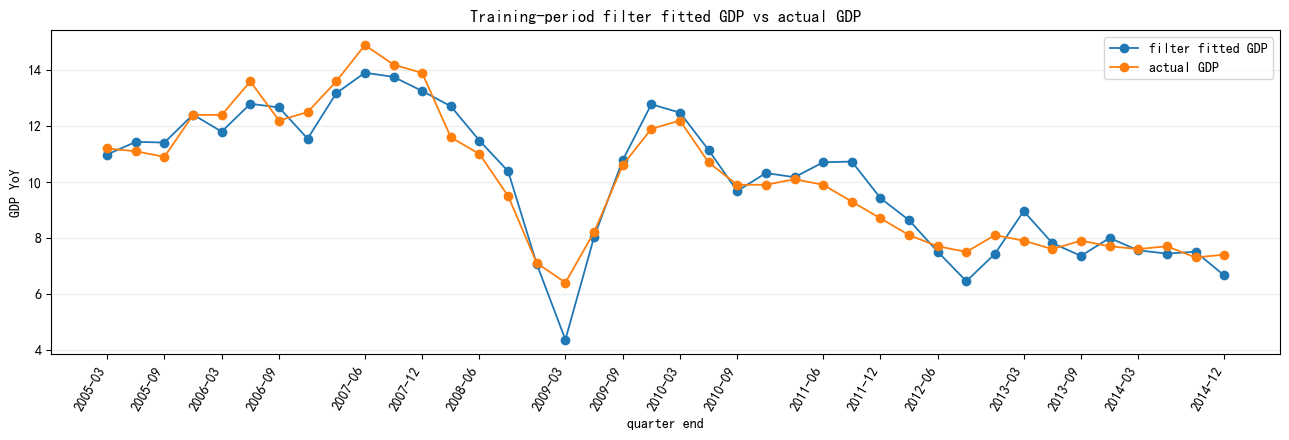

2. 训练期 smoother 拟合指标：


,value
n,40.000000
mean_error_raw,-0.016716
mae_raw,0.165032
rmse_raw,0.233770
max_abs_error_raw,0.742490
corr_raw,0.994891
r2_raw,0.989707


,smoother_gdp_pred_std,smoother_gdp_pred_raw,actual_gdp_raw,actual_gdp_std,error_raw
month,,,,,
2005-03,0.492313,11.194394,11.2,0.494746,-0.005606
2005-06,0.433535,11.058958,11.1,0.451347,-0.041042
2005-09,0.443352,11.081578,10.9,0.364550,0.181578
2005-12,0.980751,12.319859,12.4,1.015531,-0.080141
2006-03,1.109028,12.615438,12.4,1.015531,0.215438


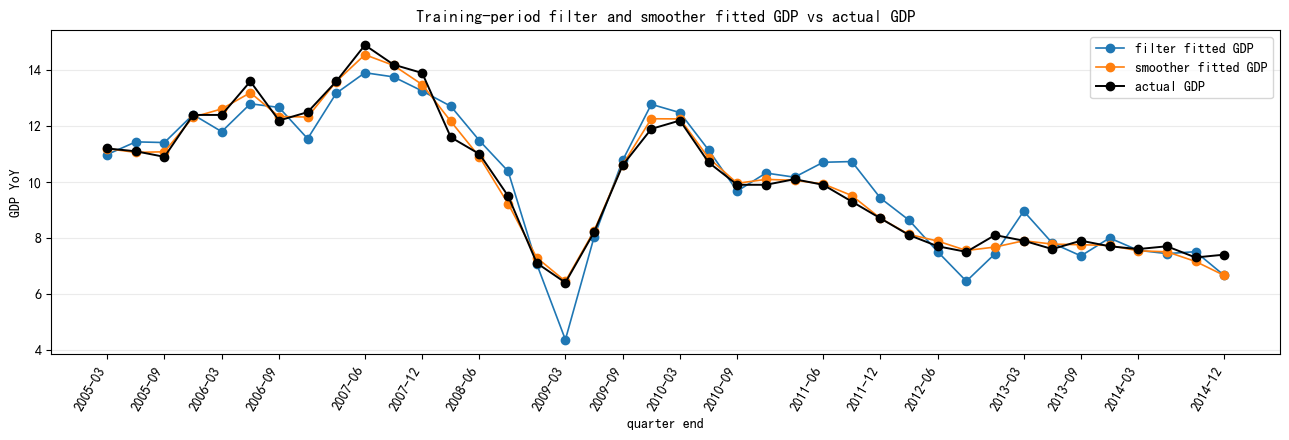

C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_filter_gdp_fit.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_filter_gdp_fit_metrics.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_filter_gdp_fit.png
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_smoother_gdp_fit.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_smoother_gdp_fit_metrics.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_filter_smoother_gdp_fit.png


In [25]:
if "em_results" in globals():
    active_results = em_results
else:
    active_results = {
        "ar_params": res["ar"],
        "loading": res["loading"],
        "h": res["h"],
        "a1": res.get("a1", pd.Series(0.0, index=STATE_NAMES)),
        "filter_results": res["filter"],
        "smoother_results": {
            "smoothed_state": res["smoother"]["state"],
            "smoothed_cov": res["smoother"].get("cov"),
        },
    }

active_ar = active_results["ar_params"]
active_loading = active_results["loading"].loc[model_cols_valid, FACTOR_NAMES]
active_h = active_results["h"].loc[model_cols_valid].clip(lower=MIN_H)
active_a1 = active_results.get("a1", pd.Series(0.0, index=STATE_NAMES)).loc[STATE_NAMES]
gdp_loading = active_results["loading"].loc[GDP_COL, FACTOR_NAMES]


def gdp_from_state(state_s: pd.Series) -> float:
    return float(sum(float(gdp_loading[f]) * float(state_s[s_name(f)]) for f in FACTOR_NAMES))


def inverse_standardize_gdp(gdp_std_value: float) -> float:
    return gdp_std_value * float(params.loc[GDP_COL, "std_train"]) + float(params.loc[GDP_COL, "mean_train"])


def quarter_end_month(m: pd.Period) -> pd.Period:
    q_end_month = ((m.month - 1) // 3 + 1) * 3
    return pd.Period(f"{m.year}-{q_end_month:02d}", freq="M")


def project_state_to_month(state_vec: np.ndarray, from_month: pd.Period, target_month: pd.Period, ar_params: pd.DataFrame) -> np.ndarray:
    out = np.asarray(state_vec, dtype=float).copy()
    cur = from_month
    while cur < target_month:
        nxt = cur + 1
        T_raw = trans(nxt, ar_params)
        T = T_raw.to_numpy(float) if hasattr(T_raw, "to_numpy") else np.asarray(T_raw, dtype=float)
        out = T @ out
        cur = nxt
    return out


def gdp_actual_raw_at(m: pd.Period) -> float:
    return float(raw.loc[m, GDP_COL]) if m in raw.index and pd.notna(raw.loc[m, GDP_COL]) else np.nan


def gdp_actual_std_at(m: pd.Period) -> float:
    return float(z_reference.loc[m, GDP_COL]) if m in z_reference.index and pd.notna(z_reference.loc[m, GDP_COL]) else np.nan


def fit_metrics(df: pd.DataFrame, pred_col: str, actual_col: str = "actual_gdp_raw", error_col: str = "error_raw") -> pd.Series:
    valid = df[[pred_col, actual_col, error_col]].dropna()
    if valid.empty:
        return pd.Series({
            "n": 0,
            "mean_error_raw": np.nan,
            "mae_raw": np.nan,
            "rmse_raw": np.nan,
            "max_abs_error_raw": np.nan,
            "corr_raw": np.nan,
            "r2_raw": np.nan,
        })
    ss_res = float((valid[error_col] ** 2).sum())
    ss_tot = float(((valid[actual_col] - valid[actual_col].mean()) ** 2).sum())
    return pd.Series({
        "n": int(len(valid)),
        "mean_error_raw": float(valid[error_col].mean()),
        "mae_raw": float(valid[error_col].abs().mean()),
        "rmse_raw": float(np.sqrt((valid[error_col] ** 2).mean())),
        "max_abs_error_raw": float(valid[error_col].abs().max()),
        "corr_raw": float(valid[[pred_col, actual_col]].corr().iloc[0, 1]) if len(valid) >= 2 else np.nan,
        "r2_raw": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
    })


def make_period_axis(ax, labels, max_ticks=18, rotation=60):
    if len(labels) == 0:
        return
    tick_idx = np.linspace(0, len(labels) - 1, min(max_ticks, len(labels)), dtype=int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([labels[i] for i in tick_idx], rotation=rotation, ha="right")


quarter_months = pd.period_range(TRAIN_START, TRAIN_END, freq="M")
quarter_months = pd.PeriodIndex([m for m in quarter_months if q_end(m) and m in raw.index])

filter_results = active_results["filter_results"]
filter_state = pd.DataFrame(filter_results["af"], index=pd.PeriodIndex(filter_results["months"], freq="M"), columns=STATE_NAMES)
filter_q = filter_state.reindex(quarter_months).dropna(how="all")
filter_pred_std = filter_q.apply(gdp_from_state, axis=1)
filter_fit = pd.DataFrame({
    TIME_COL: filter_q.index.astype(str),
    "filter_gdp_pred_std": filter_pred_std.to_numpy(float),
    "filter_gdp_pred_raw": [inverse_standardize_gdp(v) for v in filter_pred_std],
    "actual_gdp_raw": [gdp_actual_raw_at(m) for m in filter_q.index],
    "actual_gdp_std": [gdp_actual_std_at(m) for m in filter_q.index],
}).set_index(TIME_COL)
filter_fit["error_raw"] = filter_fit["filter_gdp_pred_raw"] - filter_fit["actual_gdp_raw"]
filter_metrics = fit_metrics(filter_fit, "filter_gdp_pred_raw")
filter_fit_path = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_train_filter_gdp_fit.csv"
filter_metrics_path = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_train_filter_gdp_fit_metrics.csv"
filter_fit.to_csv(filter_fit_path, encoding="utf-8-sig")
filter_metrics.to_frame("value").to_csv(filter_metrics_path, encoding="utf-8-sig")

print("1. 训练期 filter 拟合指标：")
display(filter_metrics.to_frame("value"))
display(filter_fit.head())

fig, ax = plt.subplots(figsize=(13, 4.5))
plot_filter = filter_fit[["filter_gdp_pred_raw", "actual_gdp_raw"]].copy().reset_index()
plot_filter["x"] = np.arange(len(plot_filter))
ax.plot(plot_filter["x"], plot_filter["filter_gdp_pred_raw"], marker="o", linewidth=1.3, label="filter fitted GDP")
ax.plot(plot_filter["x"], plot_filter["actual_gdp_raw"], marker="o", linewidth=1.3, label="actual GDP")
ax.set_title("Training-period filter fitted GDP vs actual GDP")
ax.set_ylabel("GDP YoY")
ax.set_xlabel("quarter end")
make_period_axis(ax, plot_filter[TIME_COL].tolist())
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
filter_fit_png = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_train_filter_gdp_fit.png"
fig.savefig(filter_fit_png, dpi=180, bbox_inches="tight")
plt.show()

smoother_state = active_results["smoother_results"].get("smoothed_state")
if smoother_state is None:
    smoother_state = active_results["smoother_results"].get("state")
smoother_state = smoother_state.copy()
smoother_state.index = pd.PeriodIndex(smoother_state.index, freq="M")
smoother_q = smoother_state.reindex(quarter_months).dropna(how="all")
smoother_pred_std = smoother_q.apply(gdp_from_state, axis=1)
smoother_fit = pd.DataFrame({
    TIME_COL: smoother_q.index.astype(str),
    "smoother_gdp_pred_std": smoother_pred_std.to_numpy(float),
    "smoother_gdp_pred_raw": [inverse_standardize_gdp(v) for v in smoother_pred_std],
    "actual_gdp_raw": [gdp_actual_raw_at(m) for m in smoother_q.index],
    "actual_gdp_std": [gdp_actual_std_at(m) for m in smoother_q.index],
}).set_index(TIME_COL)
smoother_fit["error_raw"] = smoother_fit["smoother_gdp_pred_raw"] - smoother_fit["actual_gdp_raw"]
smoother_metrics = fit_metrics(smoother_fit, "smoother_gdp_pred_raw")
smoother_fit_path = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_train_smoother_gdp_fit.csv"
smoother_metrics_path = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_train_smoother_gdp_fit_metrics.csv"
smoother_fit.to_csv(smoother_fit_path, encoding="utf-8-sig")
smoother_metrics.to_frame("value").to_csv(smoother_metrics_path, encoding="utf-8-sig")

print("2. 训练期 smoother 拟合指标：")
display(smoother_metrics.to_frame("value"))
display(smoother_fit.head())

combined_fit = filter_fit[["filter_gdp_pred_raw", "actual_gdp_raw"]].join(
    smoother_fit[["smoother_gdp_pred_raw"]],
    how="outer",
).reset_index()
combined_fit["x"] = np.arange(len(combined_fit))
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(combined_fit["x"], combined_fit["filter_gdp_pred_raw"], marker="o", linewidth=1.2, label="filter fitted GDP")
ax.plot(combined_fit["x"], combined_fit["smoother_gdp_pred_raw"], marker="o", linewidth=1.2, label="smoother fitted GDP")
ax.plot(combined_fit["x"], combined_fit["actual_gdp_raw"], marker="o", linewidth=1.4, color="black", label="actual GDP")
ax.set_title("Training-period filter and smoother fitted GDP vs actual GDP")
ax.set_ylabel("GDP YoY")
ax.set_xlabel("quarter end")
make_period_axis(ax, combined_fit[TIME_COL].tolist())
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
smoother_fit_png = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_train_filter_smoother_gdp_fit.png"
fig.savefig(smoother_fit_png, dpi=180, bbox_inches="tight")
plt.show()

print(filter_fit_path)
print(filter_metrics_path)
print(filter_fit_png)
print(smoother_fit_path)
print(smoother_metrics_path)
print(smoother_fit_png)


## 16. 训练期实时 nowcasting 诊断

本节基于第 0 步构造的 release-adjusted 面板 `z_model` 做训练期内实时 nowcasting。每个信息月只截取当月月底已经发布的数据，再运行 Kalman filter 得到当时可得信息下的 GDP 预测；不使用未来月份数据，也不使用 smoother 的事后信息。

- 月度变量按 `MONTHLY_RELEASE_LAG_DAYS = 20` 写入 `z_model`；
- GDP 按 `GDP_RELEASE_LAG_DAYS = 20` 写入 `z_model`；
- Kalman filter 每个月根据当时可见的非缺失观测更新状态；
- 当信息月不是季度末时，将当前状态向目标季度末投影，再换算为该季度 GDP nowcast；
- smoother 只用于事后拟合诊断，不用于这里的实时 nowcasting。

输出包括 nowcast 与季度末实际 GDP 的比较，以及季度内各月预测误差 `nowcast - actual GDP`。


3. 训练期实时 nowcasting：月度变量滞后 20 天，GDP 滞后 20 天。


,value
n_months,120.000000
mean_error_raw,-0.012027
mae_raw,0.605712
rmse_raw,0.811351
corr_raw,0.941408


,month,sample,information_date,release_calendar_mode,target_quarter_end,target_gdp_release_date,target_gdp_released_by_information_date,monthly_release_lag_days,gdp_release_lag_days,latest_released_monthly_period,latest_released_gdp_quarter_end,is_information_month_quarter_end,months_before_quarter_end,nowcast_gdp_std,nowcast_gdp_raw,actual_gdp_raw,actual_gdp_std,nowcast_error_raw,macro_S_target_nowcast,real_S_target_nowcast,nominal_S_target_nowcast,abs_error_raw,squared_error_raw
0,2005-01,train,2005-01-31,fixed_20_day_release_lag,2005-03,2005-04-20,False,20,20,2005-01,2005-01,False,2,0.478952,11.163608,11.2,0.494746,-0.036392,-98.450199,44.069726,0.884957,0.036392,0.001324
1,2005-02,train,2005-02-28,fixed_20_day_release_lag,2005-03,2005-04-20,False,20,20,2005-02,2005-01,False,1,0.486324,11.180595,11.2,0.494746,-0.019405,-122.671283,45.302068,0.494347,0.019405,0.000377
2,2005-03,train,2005-03-31,fixed_20_day_release_lag,2005-03,2005-04-20,False,20,20,2005-03,2005-01,True,0,0.400564,10.982985,11.2,0.494746,-0.217015,192.998203,30.138662,9.046291,0.217015,0.047096
3,2005-04,train,2005-04-30,fixed_20_day_release_lag,2005-06,2005-07-20,False,20,20,2005-04,2005-04,False,2,-1.089886,7.548671,11.1,0.451347,-3.551329,-4235.918709,8.541874,-21.024994,3.551329,12.611940
4,2005-05,train,2005-05-31,fixed_20_day_release_lag,2005-06,2005-07-20,False,20,20,2005-05,2005-04,False,1,0.474997,11.154494,11.1,0.451347,0.054494,-370.646508,50.367341,-19.183595,0.054494,0.002970
5,2005-06,train,2005-06-30,fixed_20_day_release_lag,2005-06,2005-07-20,False,20,20,2005-06,2005-04,True,0,0.597239,11.436166,11.1,0.451347,0.336166,-319.835429,59.762243,-17.556336,0.336166,0.113007
6,2005-07,train,2005-07-31,fixed_20_day_release_lag,2005-09,2005-10-20,False,20,20,2005-07,2005-07,False,2,0.802745,11.909697,10.9,0.364550,1.009697,-593.129047,84.309244,-24.727783,1.009697,1.019487
7,2005-08,train,2005-08-31,fixed_20_day_release_lag,2005-09,2005-10-20,False,20,20,2005-08,2005-07,False,1,0.826272,11.963907,10.9,0.364550,1.063907,-317.726286,79.636011,-17.061258,1.063907,1.131898
8,2005-09,train,2005-09-30,fixed_20_day_release_lag,2005-09,2005-10-20,False,20,20,2005-09,2005-07,True,0,0.586782,11.412070,10.9,0.364550,0.512070,-394.390523,60.671688,-21.118263,0.512070,0.262216
9,2005-10,train,2005-10-31,fixed_20_day_release_lag,2005-12,2006-01-20,False,20,20,2005-10,2005-10,False,2,0.696973,11.665974,12.4,1.015531,-0.734026,-620.218370,75.768327,-33.376270,0.734026,0.538794


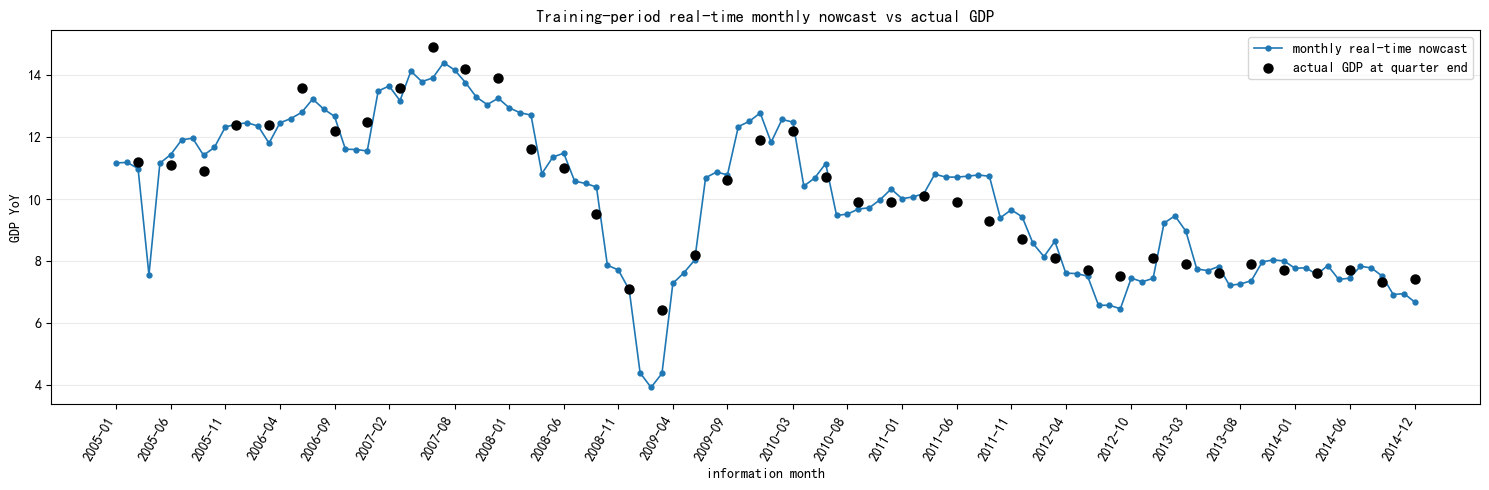

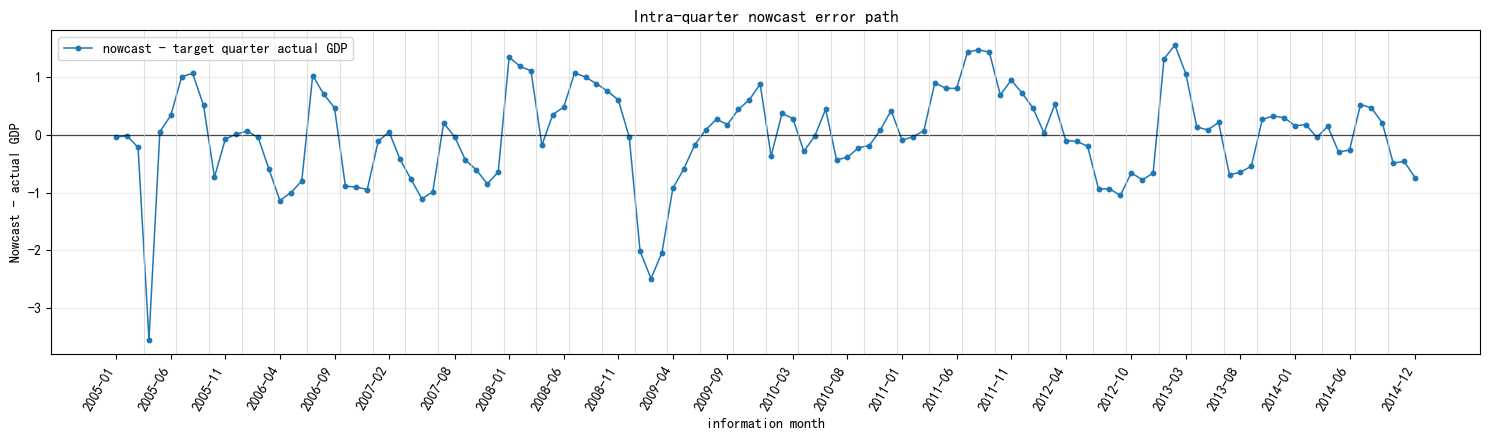

C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_realtime_monthly_nowcast.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_realtime_monthly_nowcast_metrics.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_realtime_monthly_nowcast.png
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_realtime_intraquarter_nowcast_error.png


In [26]:
def extract_available_panel(panel: pd.DataFrame):
    # z_model is already release-adjusted; slicing to the information month is the real-time vintage.
    vintage = panel.copy()
    monthly_release_available = {
        str(obs_m): bool(vintage.loc[obs_m, monthly_model_cols].notna().any())
        for obs_m in vintage.index
    }
    gdp_release_available = {
        str(obs_m): bool(pd.notna(vintage.loc[obs_m, GDP_COL]))
        for obs_m in vintage.index
    }
    return vintage, monthly_release_available, gdp_release_available

def build_realtime_nowcast(info_start: pd.Period, info_end: pd.Period, label: str) -> pd.DataFrame:
    rows = []
    for m in pd.period_range(info_start, info_end, freq="M"):
        if m not in z.index:
            continue
        target_q_end = quarter_end_month(m)
        if target_q_end not in raw.index:
            continue
        information_date = month_end_timestamp(m)
        vintage_panel, monthly_release_available, gdp_release_available = extract_available_panel(
            z_model.loc[TRAIN_START:m, model_cols_valid]
        )
        vintage_filter = kfilter_fast(
            _build_fast_panel_cache(vintage_panel),
            active_ar,
            active_loading,
            active_h,
            a1=active_a1.to_numpy(dtype=float),
            P1=None,
        )
        state_vec = vintage_filter["af"][-1]
        projected_vec = project_state_to_month(state_vec, m, target_q_end, active_ar)
        projected_state = pd.Series(projected_vec, index=STATE_NAMES)
        nowcast_std = gdp_from_state(projected_state)
        nowcast_raw = inverse_standardize_gdp(nowcast_std)
        actual_raw = gdp_actual_raw_at(target_q_end)
        actual_std = gdp_actual_std_at(target_q_end)
        latest_released_monthly = max([pd.Period(k, freq="M") for k, v in monthly_release_available.items() if v], default=pd.NaT)
        latest_released_gdp = max([pd.Period(k, freq="M") for k, v in gdp_release_available.items() if v], default=pd.NaT)
        target_gdp_released = gdp_release_timestamp(target_q_end) <= information_date
        rows.append({
            TIME_COL: str(m),
            "sample": label,
            "information_date": str(information_date.date()),
            "release_calendar_mode": RELEASE_CALENDAR_MODE,
            "target_quarter_end": str(target_q_end),
            "target_gdp_release_date": str(gdp_release_timestamp(target_q_end).date()),
            "target_gdp_released_by_information_date": bool(target_gdp_released),
            "monthly_release_lag_days": int(MONTHLY_RELEASE_LAG_DAYS),
            "gdp_release_lag_days": int(GDP_RELEASE_LAG_DAYS),
            "latest_released_monthly_period": "" if pd.isna(latest_released_monthly) else str(latest_released_monthly),
            "latest_released_gdp_quarter_end": "" if pd.isna(latest_released_gdp) else str(latest_released_gdp),
            "is_information_month_quarter_end": bool(q_end(m)),
            "months_before_quarter_end": int(target_q_end.month - m.month),
            "nowcast_gdp_std": float(nowcast_std),
            "nowcast_gdp_raw": float(nowcast_raw),
            "actual_gdp_raw": actual_raw,
            "actual_gdp_std": actual_std,
            "nowcast_error_raw": nowcast_raw - actual_raw if np.isfinite(actual_raw) else np.nan,
            **{f"{f}_S_target_nowcast": float(projected_state[s_name(f)]) for f in FACTOR_NAMES},
        })
    out = pd.DataFrame(rows)
    if not out.empty:
        out["abs_error_raw"] = out["nowcast_error_raw"].abs()
        out["squared_error_raw"] = out["nowcast_error_raw"] ** 2
    return out

def nowcast_metrics(df: pd.DataFrame) -> pd.Series:
    valid = df.dropna(subset=["nowcast_gdp_raw", "actual_gdp_raw", "nowcast_error_raw"])
    if valid.empty:
        return pd.Series({"n_months": 0, "mean_error_raw": np.nan, "mae_raw": np.nan, "rmse_raw": np.nan, "corr_raw": np.nan})
    return pd.Series({
        "n_months": int(len(valid)),
        "mean_error_raw": float(valid["nowcast_error_raw"].mean()),
        "mae_raw": float(valid["abs_error_raw"].mean()),
        "rmse_raw": float(np.sqrt(valid["squared_error_raw"].mean())),
        "corr_raw": float(valid[["nowcast_gdp_raw", "actual_gdp_raw"]].corr().iloc[0, 1]) if len(valid) >= 2 else np.nan,
    })


def plot_monthly_nowcast_vs_actual(df: pd.DataFrame, title: str, png_path: Path):
    plot_df = df.dropna(subset=["nowcast_gdp_raw"]).copy().reset_index(drop=True)
    plot_df["x"] = np.arange(len(plot_df))
    actual_points = plot_df.loc[plot_df[TIME_COL] == plot_df["target_quarter_end"]].dropna(subset=["actual_gdp_raw"])

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(plot_df["x"], plot_df["nowcast_gdp_raw"], marker="o", markersize=3.5, linewidth=1.2, label="monthly real-time nowcast")
    if not actual_points.empty:
        ax.scatter(actual_points["x"], actual_points["actual_gdp_raw"], color="black", s=42, zorder=4, label="actual GDP at quarter end")
    ax.set_title(title)
    ax.set_ylabel("GDP YoY")
    ax.set_xlabel("information month")
    make_period_axis(ax, plot_df[TIME_COL].tolist(), max_ticks=24)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    plt.show()


train_nowcast = build_realtime_nowcast(TRAIN_START, TRAIN_END, "train")
train_nowcast_path = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_train_realtime_monthly_nowcast.csv"
train_nowcast.to_csv(train_nowcast_path, encoding="utf-8-sig", index=False)
train_nowcast_metrics = nowcast_metrics(train_nowcast)
train_nowcast_metrics_path = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_train_realtime_monthly_nowcast_metrics.csv"
train_nowcast_metrics.to_frame("value").to_csv(train_nowcast_metrics_path, encoding="utf-8-sig")

print(f"3. 训练期实时 nowcasting：月度变量滞后 {MONTHLY_RELEASE_LAG_DAYS} 天，GDP 滞后 {GDP_RELEASE_LAG_DAYS} 天。")
display(train_nowcast_metrics.to_frame("value"))
display(train_nowcast.head(12))

train_nowcast_png = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_train_realtime_monthly_nowcast.png"
plot_monthly_nowcast_vs_actual(train_nowcast, "Training-period real-time monthly nowcast vs actual GDP", train_nowcast_png)

error_plot = train_nowcast.dropna(subset=["nowcast_error_raw"]).copy().reset_index(drop=True)
error_plot["x"] = np.arange(len(error_plot))
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(error_plot["x"], error_plot["nowcast_error_raw"], marker="o", markersize=3.2, linewidth=1.1, label="nowcast - target quarter actual GDP")
ax.axhline(0, color="black", linewidth=0.9, alpha=0.7)
for target_q_end, group in error_plot.groupby("target_quarter_end", sort=False):
    x_end = float(group["x"].max())
    if x_end < error_plot["x"].max():
        ax.axvline(x_end + 0.5, color="lightgray", linewidth=0.8, alpha=0.7)
ax.set_title("Intra-quarter nowcast error path")
ax.set_ylabel("Nowcast - actual GDP")
ax.set_xlabel("information month")
make_period_axis(ax, error_plot[TIME_COL].tolist(), max_ticks=24)
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
intra_error_png = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_train_realtime_intraquarter_nowcast_error.png"
fig.savefig(intra_error_png, dpi=180, bbox_inches="tight")
plt.show()

print(train_nowcast_path)
print(train_nowcast_metrics_path)
print(train_nowcast_png)
print(intra_error_png)


## 17. 训练窗口后一年的实时 nowcasting 对比

本节使用同一组训练期估计参数，向训练窗口之后 12 个月做实时 nowcasting 检查。

- 参数不重新估计；
- 每个信息月只使用截至该月月底已发布的数据；
- nowcast 按月展示；
- 真实 GDP 只在季度末打点展示。


4. 训练窗口后一年的实时 nowcasting：


,value
n_months,12.000000
mean_error_raw,-0.283937
mae_raw,0.469320
rmse_raw,0.553077
corr_raw,0.321738


,month,sample,information_date,release_calendar_mode,target_quarter_end,target_gdp_release_date,target_gdp_released_by_information_date,monthly_release_lag_days,gdp_release_lag_days,latest_released_monthly_period,latest_released_gdp_quarter_end,is_information_month_quarter_end,months_before_quarter_end,nowcast_gdp_std,nowcast_gdp_raw,actual_gdp_raw,actual_gdp_std,nowcast_error_raw,macro_S_target_nowcast,real_S_target_nowcast,nominal_S_target_nowcast,abs_error_raw,squared_error_raw
0,2015-01,post_train_1y,2015-01-31,fixed_20_day_release_lag,2015-03,2015-04-20,False,20,20,2015-01,2015-01,False,2,-1.098301,7.529280,7.1,-1.284603,0.429280,-114.424665,-92.757033,-15.396405,0.429280,0.184281
1,2015-02,post_train_1y,2015-02-28,fixed_20_day_release_lag,2015-03,2015-04-20,False,20,20,2015-02,2015-01,False,1,-1.112348,7.496914,7.1,-1.284603,0.396914,-352.675651,-88.165590,-32.198502,0.396914,0.157540
2,2015-03,post_train_1y,2015-03-31,fixed_20_day_release_lag,2015-03,2015-04-20,False,20,20,2015-03,2015-01,True,0,-1.385165,6.868285,7.1,-1.284603,-0.231715,-208.794119,-115.410681,-22.680575,0.231715,0.053692
3,2015-04,post_train_1y,2015-04-30,fixed_20_day_release_lag,2015-06,2015-07-20,False,20,20,2015-04,2015-04,False,2,-1.351578,6.945676,7.1,-1.284603,-0.154324,-150.636818,-113.907799,-16.565255,0.154324,0.023816
4,2015-05,post_train_1y,2015-05-31,fixed_20_day_release_lag,2015-06,2015-07-20,False,20,20,2015-05,2015-04,False,1,-1.561153,6.462771,7.1,-1.284603,-0.637229,-173.437136,-131.583878,-20.043351,0.637229,0.406061
5,2015-06,post_train_1y,2015-06-30,fixed_20_day_release_lag,2015-06,2015-07-20,False,20,20,2015-06,2015-04,True,0,-1.741658,6.046847,7.1,-1.284603,-1.053153,-224.073218,-146.051814,-22.957564,1.053153,1.109131
6,2015-07,post_train_1y,2015-07-31,fixed_20_day_release_lag,2015-09,2015-10-20,False,20,20,2015-07,2015-07,False,2,-1.269586,7.134603,7.0,-1.328002,0.134603,-70.521762,-108.729598,-15.797651,0.134603,0.018118
7,2015-08,post_train_1y,2015-08-31,fixed_20_day_release_lag,2015-09,2015-10-20,False,20,20,2015-08,2015-07,False,1,-1.461489,6.692418,7.0,-1.328002,-0.307582,-54.518962,-125.815052,-14.074209,0.307582,0.094606
8,2015-09,post_train_1y,2015-09-30,fixed_20_day_release_lag,2015-09,2015-10-20,False,20,20,2015-09,2015-07,True,0,-1.686799,6.173256,7.0,-1.328002,-0.826744,-76.873916,-144.870907,-15.122072,0.826744,0.683506
9,2015-10,post_train_1y,2015-10-31,fixed_20_day_release_lag,2015-12,2016-01-20,False,20,20,2015-10,2015-10,False,2,-1.305651,7.051500,6.9,-1.371401,0.151500,-67.132638,-111.949888,-13.800859,0.151500,0.022952


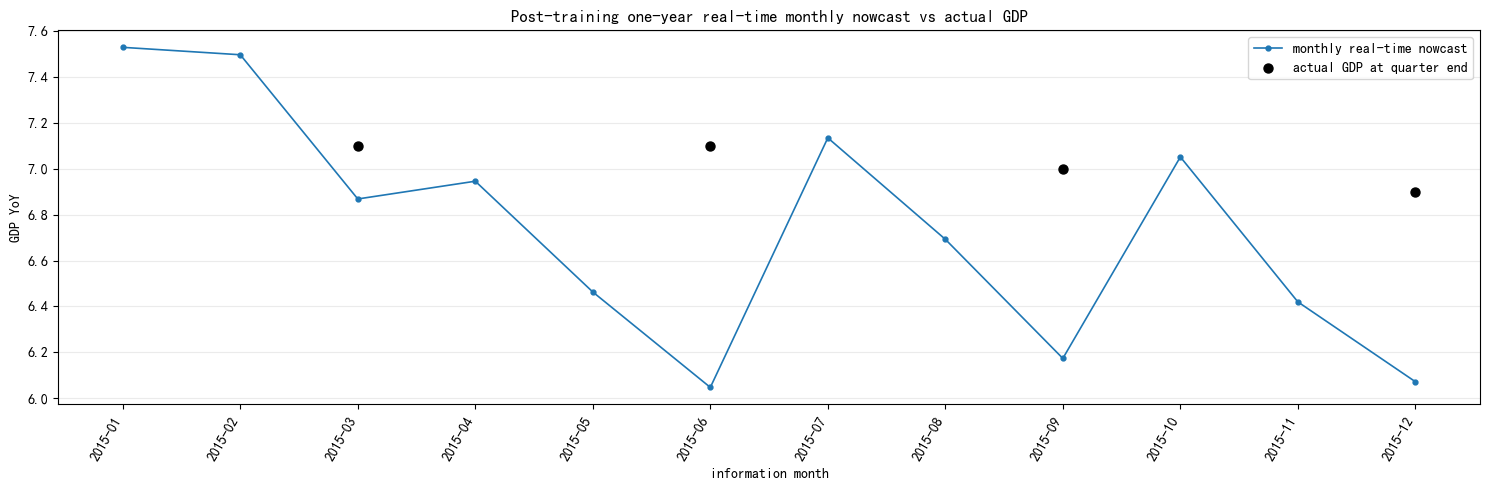

C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_post_train_1y_realtime_monthly_nowcast.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_post_train_1y_realtime_monthly_nowcast_metrics.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_post_train_1y_realtime_monthly_nowcast.png


In [27]:
FORECAST_START = TRAIN_END + 1
FORECAST_END = TRAIN_END + 12
future_nowcast = build_realtime_nowcast(FORECAST_START, FORECAST_END, "post_train_1y")
future_nowcast_path = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_post_train_1y_realtime_monthly_nowcast.csv"
future_nowcast.to_csv(future_nowcast_path, encoding="utf-8-sig", index=False)
future_nowcast_metrics = nowcast_metrics(future_nowcast)
future_nowcast_metrics_path = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_post_train_1y_realtime_monthly_nowcast_metrics.csv"
future_nowcast_metrics.to_frame("value").to_csv(future_nowcast_metrics_path, encoding="utf-8-sig")

print("4. 训练窗口后一年的实时 nowcasting：")
display(future_nowcast_metrics.to_frame("value"))
display(future_nowcast)

future_nowcast_png = ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_post_train_1y_realtime_monthly_nowcast.png"
plot_monthly_nowcast_vs_actual(
    future_nowcast,
    "Post-training one-year real-time monthly nowcast vs actual GDP",
    future_nowcast_png,
)

print(future_nowcast_path)
print(future_nowcast_metrics_path)
print(future_nowcast_png)


### Runtime profiling


In [28]:
profiling_records = globals().get('profiling_records', [])
profiling_df = pd.DataFrame(profiling_records)
if profiling_df.empty:
    profiling_df = pd.DataFrame([
        {'phase': 'EM', 'runtime_seconds': globals().get('em_runtime_seconds', np.nan)},
        {'phase': 'QN', 'runtime_seconds': globals().get('qn_runtime_seconds', np.nan)},
    ])
else:
    profiling_df = profiling_df.drop_duplicates(subset=['phase'], keep='last')

phase_order = ['EM', 'QN']
if 'QN' not in profiling_df['phase'].tolist():
    profiling_df = pd.concat([
        profiling_df,
        pd.DataFrame([{'phase': 'QN', 'runtime_seconds': globals().get('qn_runtime_seconds', np.nan)}]),
    ], ignore_index=True)
profiling_df['phase'] = pd.Categorical(profiling_df['phase'], categories=phase_order, ordered=True)
profiling_df = profiling_df.sort_values('phase').reset_index(drop=True)
profiling_df['runtime_minutes'] = profiling_df['runtime_seconds'] / 60
print('EM / QN runtime profiling:')
display(profiling_df)


EM / QN runtime profiling:


,phase,runtime_seconds,runtime_minutes
0,EM,60.485364,1.008089
1,QN,69.357468,1.155958
